# **Нелинейные модели против южной погоды**

---

**Описание исследования**

Необходимо построить модель машинного обучения для прогнозирования почасового спроса на аренду велосипедов по погодным и календарным условиям. Задача регрессии - предсказать числовое значение целевой переменной по набору факторов, чтобы улучшить точность прогнозов и стабилизировать логистику (избежать дефицита и простоев велосипедов).​

---

**Цель исследования**

Разработать и обучить модель машинного обучения для прогнозирования почасового спроса на велопрокат.

- Целевая переменная: Rented Bike Count (регрессия).
- Базовое решение: оценить предоставленный заказчиком pipeline с линейной регрессией (pickle) на train и test по метрикам RMSE, R^2, MAE.
- Основные модели для улучшения: kNN-регрессия и дерево решений + подбор гиперпараметров через Optuna (подход define-by-run).​
- Основная метрика для оптимизации: RMSE (минимизация); для корректной работы со scoring в cross_val_score использовать neg_root_mean_squared_error 

---

**Задачи исследования**

- Подготовка среды и загрузка данных.
- Запуск baseline-пайплайна с линейной регрессией (pickle) и оценка RMSE/R^2/MAE на train и test.
- EDA и подготовка данных (типы, пропуски, распределение Rented Bike Count, гипотезы о нелинейностях).
- Обучение и подбор гиперпараметров kNN и дерева решений с Optuna.
- Сравнение лучших моделей, выбор победителя и единственная финальная проверка на test.
- Интерпретация (важность признаков) и выводы/рекомендации для BikeSouth.

---

Файлы: ds_s14_train_data.csv (обучение/валидация) и ds_s14_test_data.csv (финальная оценка).

Признаки: 
- погодные (Temperature, Humidity, Windspeed, Visibility, Dew Point Temperature, Solar Radiation, Rainfall, Snowfall)

- сезон/календарь (Seasons, Holiday, Functioning Day)

- временные периоды (Time_Period*, где Daytime - базовый период)

Целевая переменная: Rented Bike Count.

---

## Подготовка среды и библиотек

#### 1.1 Подготовка библиотек


In [1]:
from pathlib import Path

req_path = Path("../../requirements.txt")
if req_path.exists():
    %pip install -qr {req_path}
else:
    %pip install -qU numpy scipy scikit-learn==1.6.1 pandas matplotlib seaborn phik joblib category_encoders optuna


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import joblib
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold, RFE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

from IPython.display import display

pd.set_option('display.max_columns', None)

/Users/katsay/develop/ml/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
RANDOM_STATE=42

In [4]:
print(sklearn.__version__) 

1.6.1


---

In [5]:
def get_df(path):
    return pd.read_csv(path, sep=',', decimal='.')

base_path = '/datasets/'
train_pth1 = Path(f'.{base_path}ds_s14_train_data.csv')
train_pth2 = Path(f'{base_path}ds_s14_train_data.csv')

test_pth1 = Path(f'.{base_path}ds_s14_test_data.csv')
test_pth2 = Path(f'{base_path}ds_s14_test_data.csv')

baseline_pth1 = Path('./models/baseline_linear_regression_pipeline.pkl')
baseline_pth2 = Path(f'{base_path}baseline_linear_regression_pipeline.pkl')

if train_pth1.exists() and test_pth1.exists() and baseline_pth1.exists():
    train = get_df(train_pth1)
    test = get_df(test_pth1)
    baseline = joblib.load(baseline_pth1)
elif train_pth2.exists() and test_pth2.exists() and baseline_pth2.exists():
    train = get_df(train_pth2)
    test = get_df(test_pth2)
    baseline = joblib.load(baseline_pth2)
else:
    raise "Путь до датасета неверный"

In [6]:
print('train')
display(train.head())
train.info()
print()
print('test')
display(test.head())
test.info()

train


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


<class 'pandas.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   str    
 9   Holiday                   1752 non-null   str    
 10  Functioning Day           1752 non-null   str    
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Period_Night  

## **Часть 1. Работа с базовой моделью**

Сперва вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSouth до того, как обратилась к вам.

Компания предоставила:

* Pickle-файл - готовый обученный пайплайн без исходного кода. Доступен по пути здесь: `'/datasets/baseline_linear_regression_pipeline.pkl'`.

* Тренировочную и тестовую выборки, которые можно использовать для оценки модели. Они расположены здесь:

  * `'/datasets/ds_s14_train_data.csv'`;
  * `'/datasets/ds_s14_test_data.csv'`.


Базовую модель не нужно обучать заново - достаточно загрузить её и проверить качество.

**Совет:**
1. Убедитесь, что у вас есть доступ к `baseline_linear_regression_pipeline.pkl`, `ds_s14_train_data.csv` и `ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки `X` и целевую переменную `y`.

3. Загрузите .pkl-файл - это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R² - эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [8]:
X = train.drop(columns=['Rented Bike Count'])
y = train['Rented Bike Count']

In [9]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    shuffle=True,
    test_size=.2,
    random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_train_val.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Среднее значенее целевой переменной в train: {y_train_val.mean():.3f}")
print(f"Среднее значенее целевой переменной в test: {y_test.mean():.3f}")

Размер обучающей выборки: (5606, 15)
Размер тестовой выборки: (1402, 15)
Среднее значенее целевой переменной в train: 705.099
Среднее значенее целевой переменной в test: 707.633


In [10]:
def compute_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

wape_scorer = make_scorer(compute_wape, greater_is_better=False)

In [11]:
def show_metrics(name, pipeline):
    scoring = {
        "RMSE": "neg_root_mean_squared_error",
        "MAE":  "neg_mean_absolute_error",
        "R2":   "r2",
        "WAPE": wape_scorer,
    }

    cv_results = cross_validate(
        pipeline, 
        X_train_val, 
        y_train_val,
        cv=cv, 
        scoring=scoring, 
        n_jobs=5,
    )

    cv_row = {
        "Phase": "Cross-Val (Mean)",
        "Model": name,
        "RMSE":  -cv_results["test_RMSE"].mean(),
        "MAE":   -cv_results["test_MAE"].mean(),
        "R2":     cv_results["test_R2"].mean(),
        "WAPE%": -cv_results["test_WAPE"].mean(),
    }

    pipeline.fit(X_train_val, y_train_val)
    y_pred = pipeline.predict(X_test)

    test_row = {
        "Phase": "Test",
        "Model": name,
        "RMSE":  root_mean_squared_error(y_test, y_pred),
        "MAE":   mean_absolute_error(y_test, y_pred),
        "R2":    r2_score(y_test, y_pred),
        "WAPE%": compute_wape(y_test, y_pred),
    }

    metrics_df = pd.DataFrame([cv_row, test_row]).round(2)
    display(metrics_df)
    
    _, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=ax_scatter)
    limits = [y_test.min(), y_test.max()]
    ax_scatter.plot(limits, limits, "--r", linewidth=2)
    ax_scatter.set(
        title=f"{name} - Actual vs Predicted",
        xlabel="Actual (y)",
        ylabel="Predicted (ŷ)",
    )
    ax_scatter.grid(True)

    errors = y_test - y_pred
    sns.histplot(errors, kde=True, bins=30, ax=ax_hist)
    ax_hist.axvline(0, color="red", linestyle="--")
    ax_hist.set(
        title=f"{name} - Распределение ошибок",
        xlabel="Error (y − ŷ)",
    )

    plt.tight_layout()
    plt.show()
    
    return metrics_df

,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Linear Regression (baseline),413.41,309.72,0.59,43.94
1,Test,Linear Regression (baseline),413.56,313.12,0.59,44.25


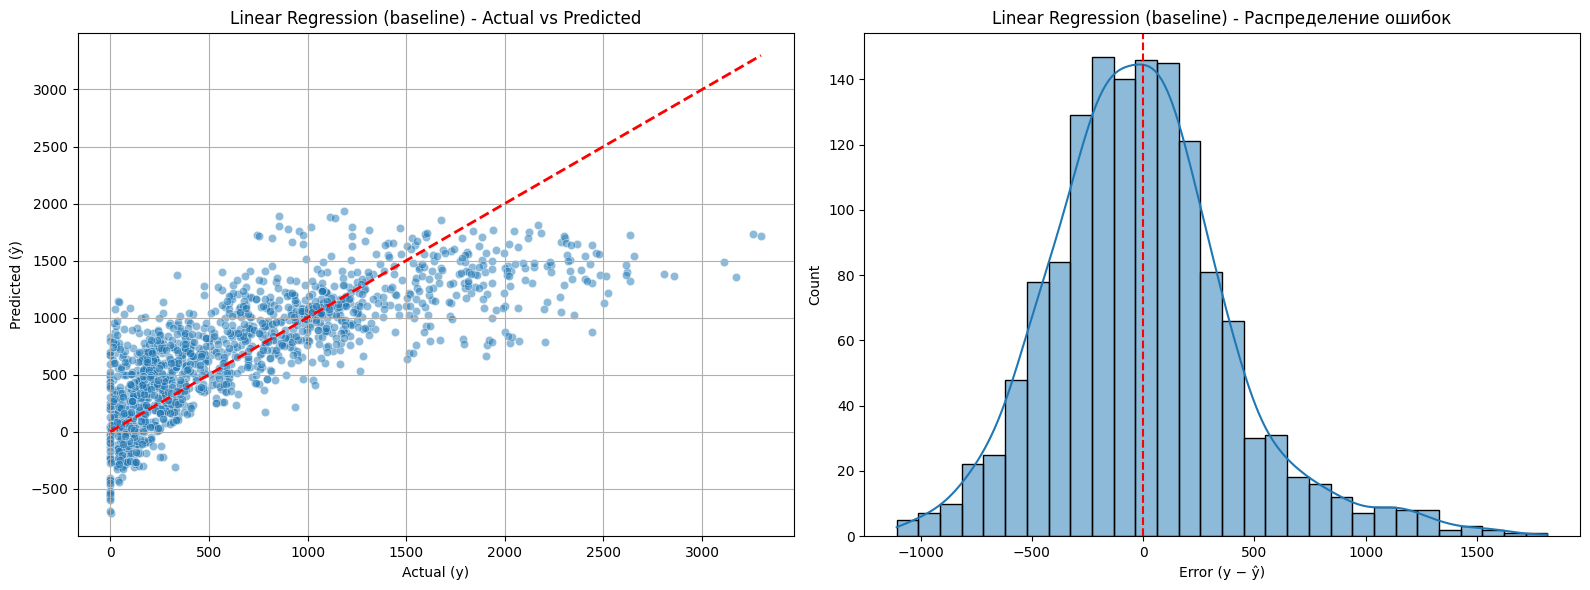

In [12]:
lr_metrics_df = show_metrics('Linear Regression (baseline)', baseline)

## **Часть 2. Улучшение модели - kNN и дерево решений**

Ваша задача - предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы погоды и поведение клиентов.

Вы будете экспериментировать с моделями kNN и деревьями решений, используя подбор гиперпараметров Optuna.

**Шаг 1. Изучение данных**

Проведите исследовательский анализ данных:
1. Посмотрите на распределение целевой переменной `Rented Bike Count`. Определите, есть ли у неё выбросы или сильные сезонные колебания.
2. Постройте графики зависимости спроса от разных признаков.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Рассчитайте корреляцию между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять: начните с базовых графиков и описательной статистики.

---

In [13]:
print("Явные дубликаты строк:", train.duplicated().sum())
train = train.drop_duplicates(keep='first')

Явные дубликаты строк: 0


In [14]:
num_cols = train.select_dtypes(include=['number']).columns
cat_cols = train.select_dtypes(include=['str']).columns
bool_cols = train.select_dtypes(include=['bool']).columns

In [15]:
df_eda = train.copy()

In [16]:
rbc = df_eda['Rented Bike Count']

rbc.describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64

In [17]:
def show_hist(data, name, xlabel='Признак'):    
    ax = data.plot(
        kind='hist',
        title=f'Распределение {name}',
        xlabel=xlabel,
        ylabel='Количетсво',
        rot=30,
        bins=20,
        figsize=(14, 4),
    )

    ax.bar_label(ax.containers[0], label_type='center')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()
    plt.close()

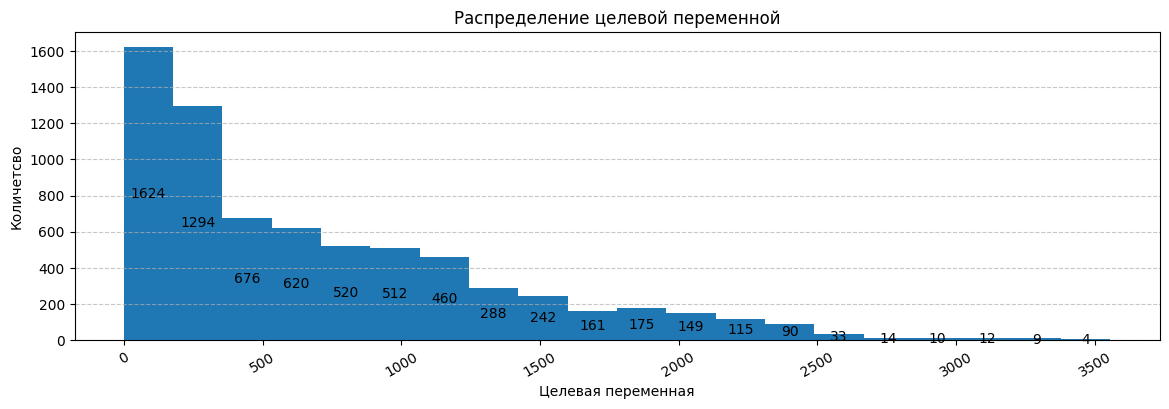

In [18]:
show_hist(rbc, 'целевой переменной', 'Целевая переменная')

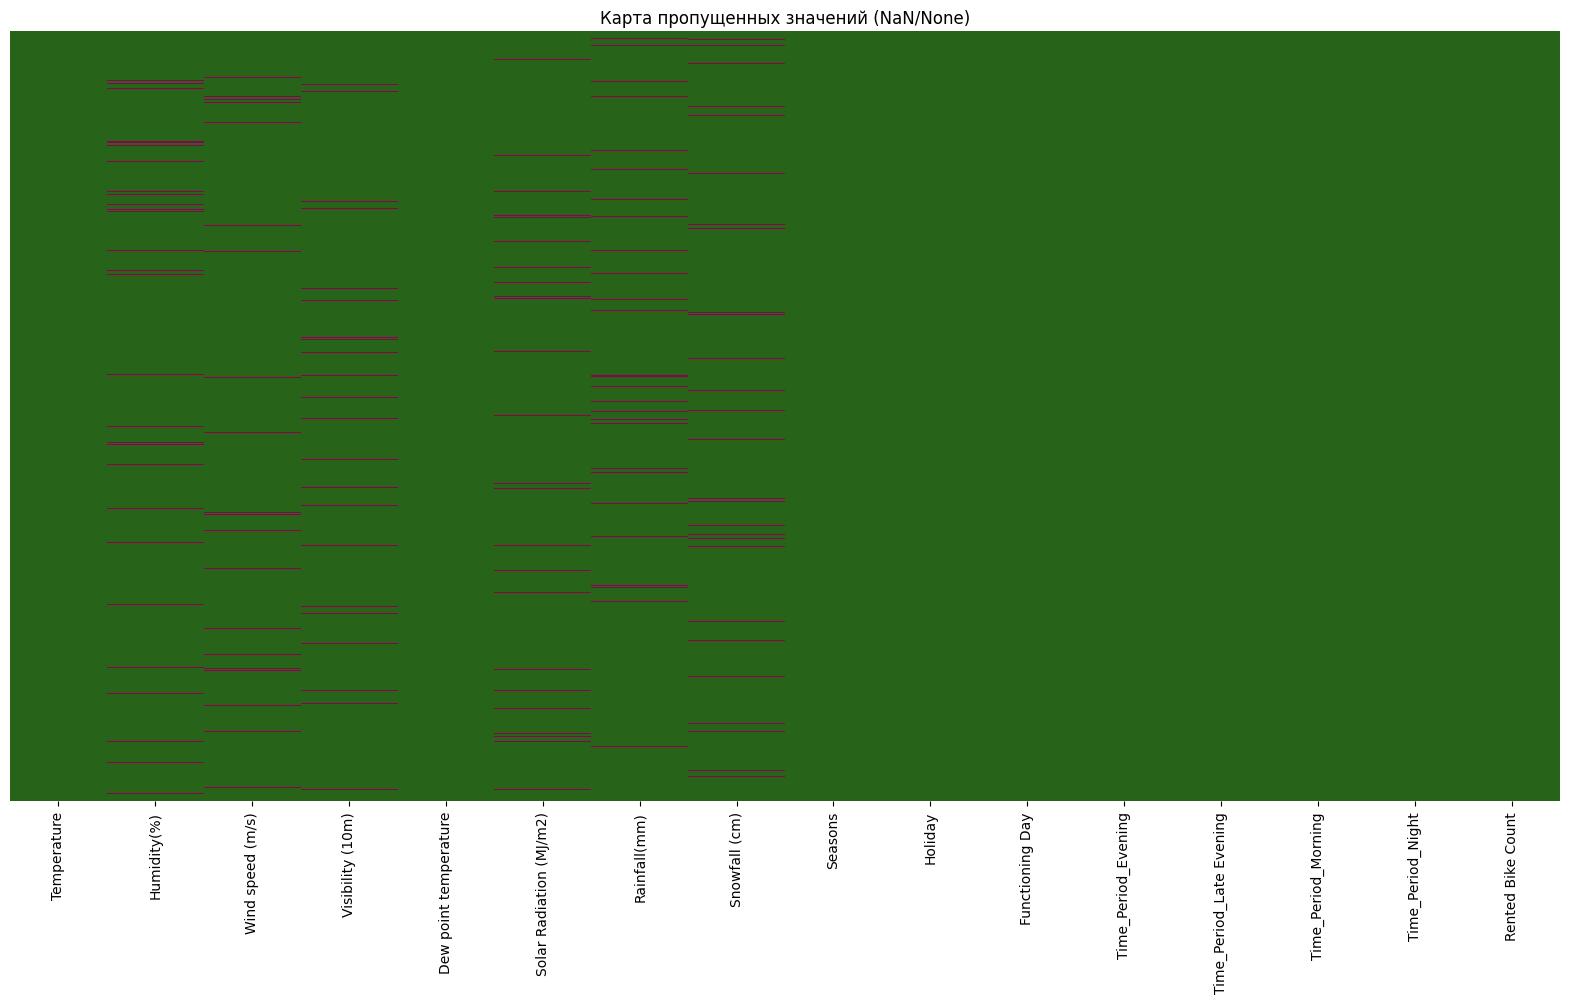

In [19]:
fig, ax = plt.subplots(figsize=(20,10)) 
sns.heatmap(df_eda.isna().astype(int), yticklabels=False, cbar=False, cmap='PiYG_r', xticklabels=df_eda.columns)

plt.title("Карта пропущенных значений (NaN/None)")
plt.show()

In [20]:
def check_num_features(df, cols):
    data = []
    for col in cols:
        data.append({
            'Признак': col,
            'Кол-во': df[col].nunique(),
        })
        
    return pd.DataFrame(data)

check_num_features(df_eda, num_cols)

,Признак,Кол-во
0,Temperature,541
1,Humidity(%),87
2,Wind speed (m/s),64
3,Visibility (10m),1697
4,Dew point temperature,547
5,Solar Radiation (MJ/m2),344
6,Rainfall(mm),53
7,Snowfall (cm),47
8,Rented Bike Count,2024


In [21]:
def create_df_boxplot(data, ax):
    sns.boxplot(data=data, ax=ax)
    
    title = 'Размах значений признака'

    ax.set_title(title)
    ax.set_ylabel('Значение признака')

    ax.grid(True)
    ax.tick_params(axis='x', rotation=30)

In [22]:
def create_df_hist(data, col):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 2))
    
    hist = axes[0]
    data.plot(
        kind='hist',
        bins=70,
        grid=True,
        ax=hist
    )
    
    hist.set_title(f'Распределение значений признака: {col}')
    hist.set_xlabel('Значение признака')
    hist.set_ylabel('Количество значений')
    hist.set_yscale('log')
    
    create_df_boxplot(data, axes[1])
    
    plt.show()
    plt.close()

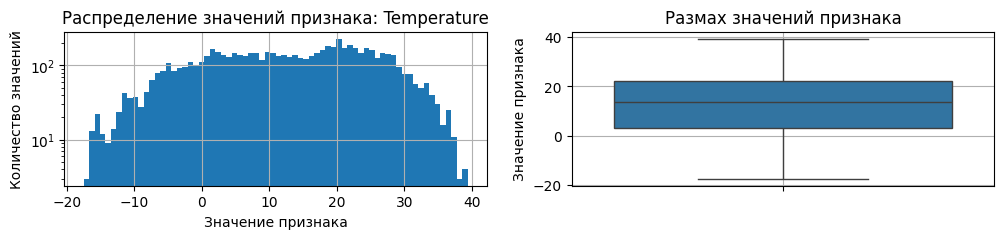

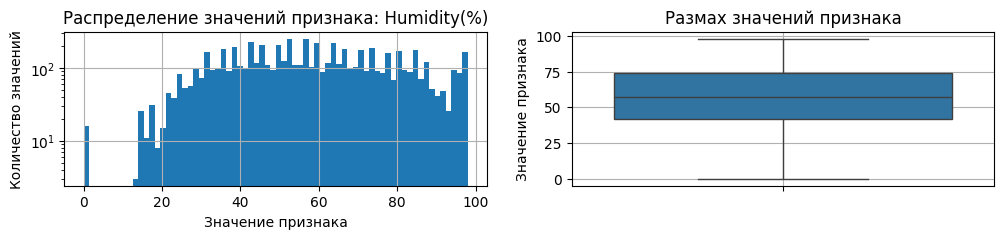

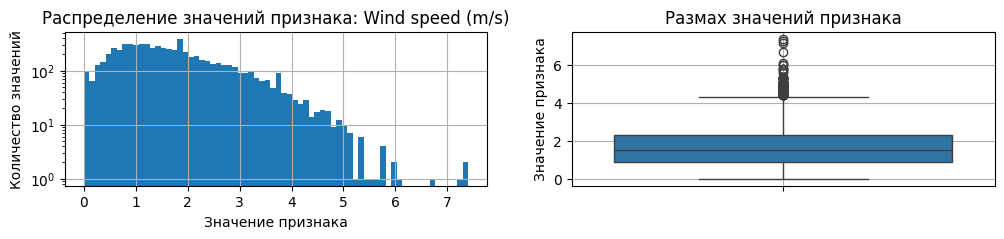

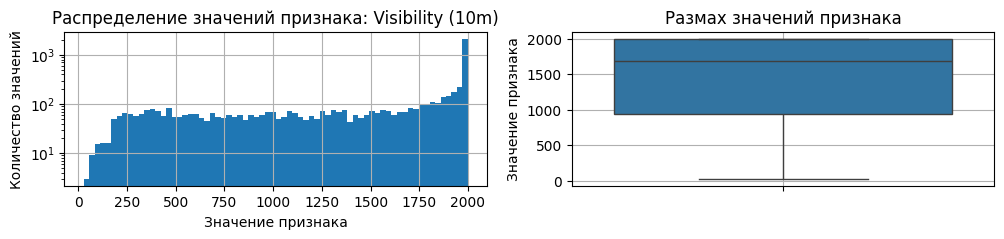

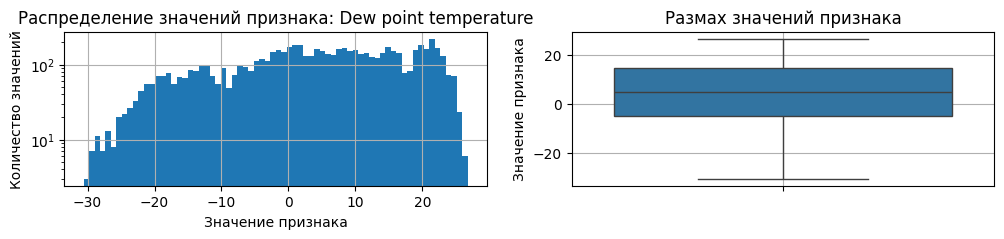

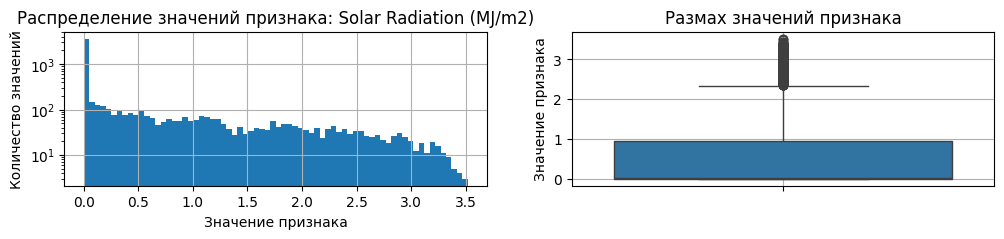

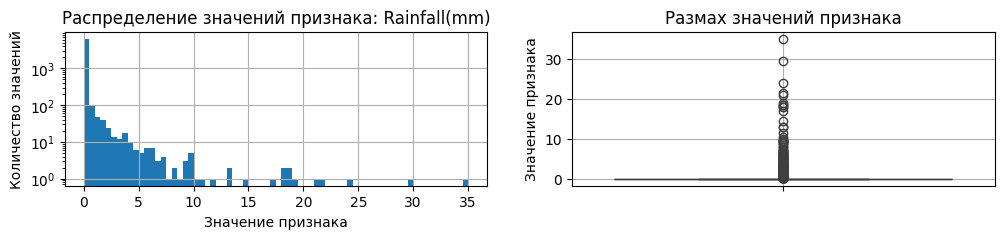

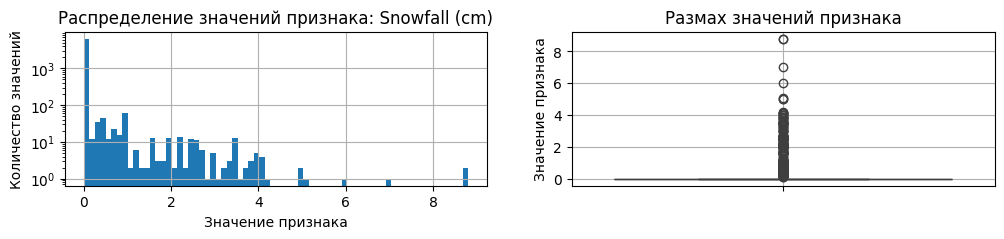

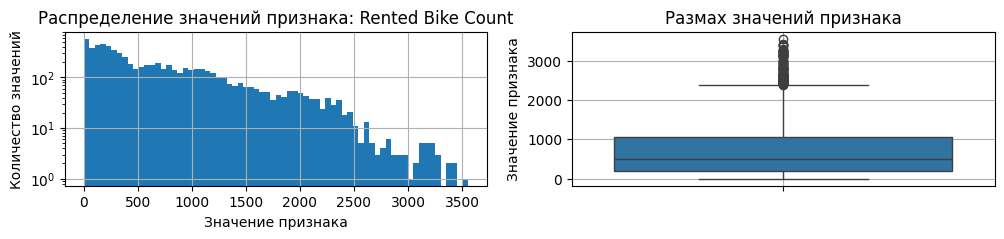

In [23]:
for col in num_cols:
    create_df_hist(df_eda[col], col)

In [24]:
def check_cat_features(df, cols):
    data = []
    for col in cols:
        data.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': df[col].nunique(),
        })
        
    return pd.DataFrame(data)

check_cat_features(df_eda, cat_cols)

,Признак,Уникальные значения,Кол-во
0,Seasons,"[Autumn, Winter, Summer, Spring]",4
1,Holiday,"[Holiday, No Holiday]",2
2,Functioning Day,"[Yes, No]",2


In [25]:
def show_countplot(df_eda, col):
    plt.figure(figsize=(12, 2)) 
    
    ax = sns.countplot(
        x=col,
        data=df_eda,
        hue=col, 
        legend=False,
        palette='viridis', 
        dodge=False,
    )
    
    plt.title(f'Распределение: {col}')
    plt.xlabel('')
    plt.ylabel('Количество')

    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)

    plt.tight_layout()
    plt.show()
    
    plt.close()

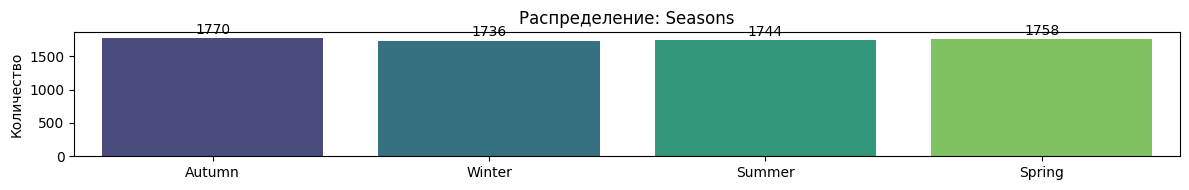

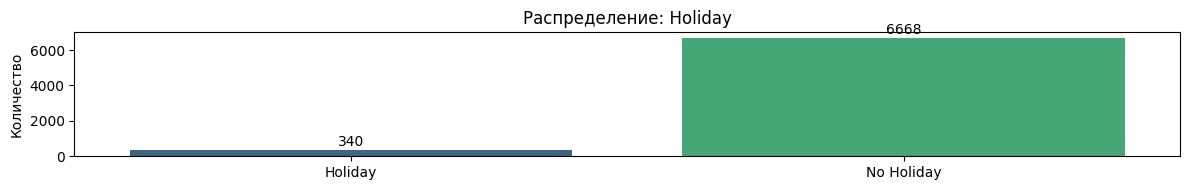

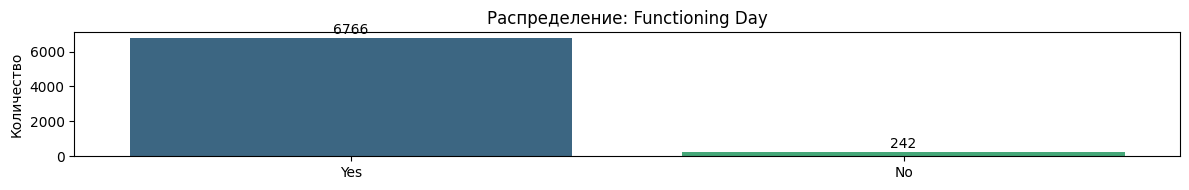

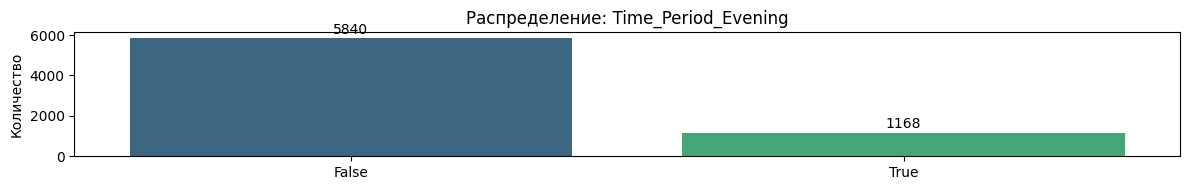

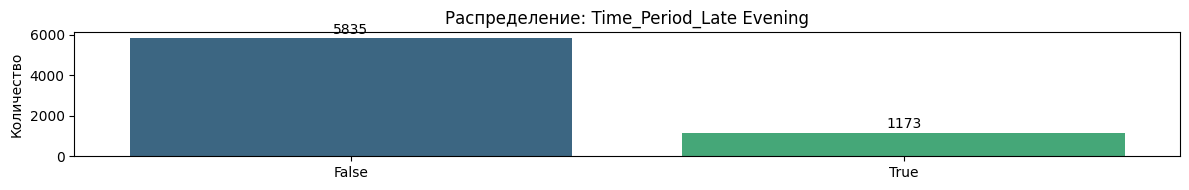

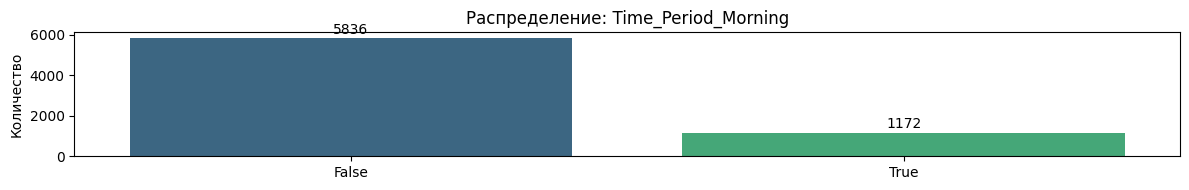

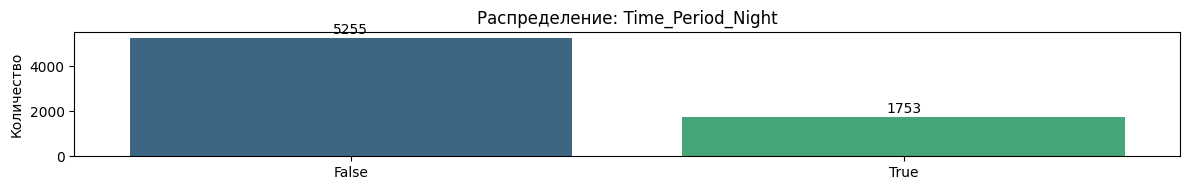

In [26]:
for col in cat_cols.append(bool_cols):
    show_countplot(df_eda, col)

In [27]:
def show_missing_stats(df):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isna().sum(),
        'Доля пропусков': df.isna().mean() * 100
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return missing_stats \
            .sort_values(by='Кол-во пропусков', ascending=False) \
            .style.format({'Доля пропусков': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm')

In [28]:
show_missing_stats(df_eda)

,Кол-во пропусков,Доля пропусков
Snowfall (cm),263,3.75%
Rainfall(mm),262,3.74%
Visibility (10m),259,3.70%
Humidity(%),250,3.57%
Wind speed (m/s),210,3.00%
Solar Radiation (MJ/m2),210,3.00%


In [29]:
cols_to_fix = [
    'Snowfall (cm)', 'Rainfall(mm)', 'Visibility (10m)', 
    'Humidity(%)', 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'
]

df_eda[cols_to_fix] = df_eda[cols_to_fix].fillna(df_eda[cols_to_fix].median())

In [30]:
show_missing_stats(df_eda)

'Пропусков в данных нет'

In [31]:
def create_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef) 
    plt.figure(figsize=(x, dynamic_height)) 
    
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=.5,
        cbar=False,
    )
    
    plt.title(title)

    plt.show()

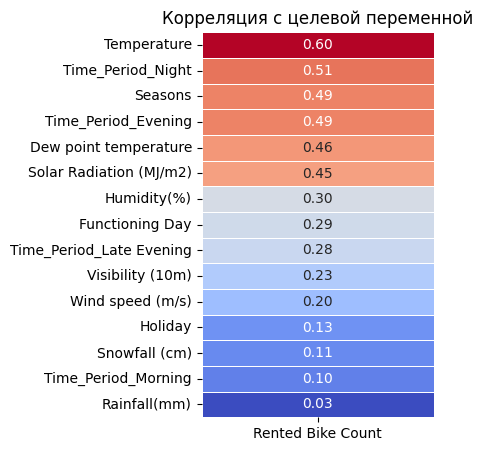

In [32]:
corr_matrix = df_eda.phik_matrix(njobs=4, interval_cols=['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count'])
target_corr = corr_matrix[corr_matrix.index != 'Rented Bike Count'][['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

create_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

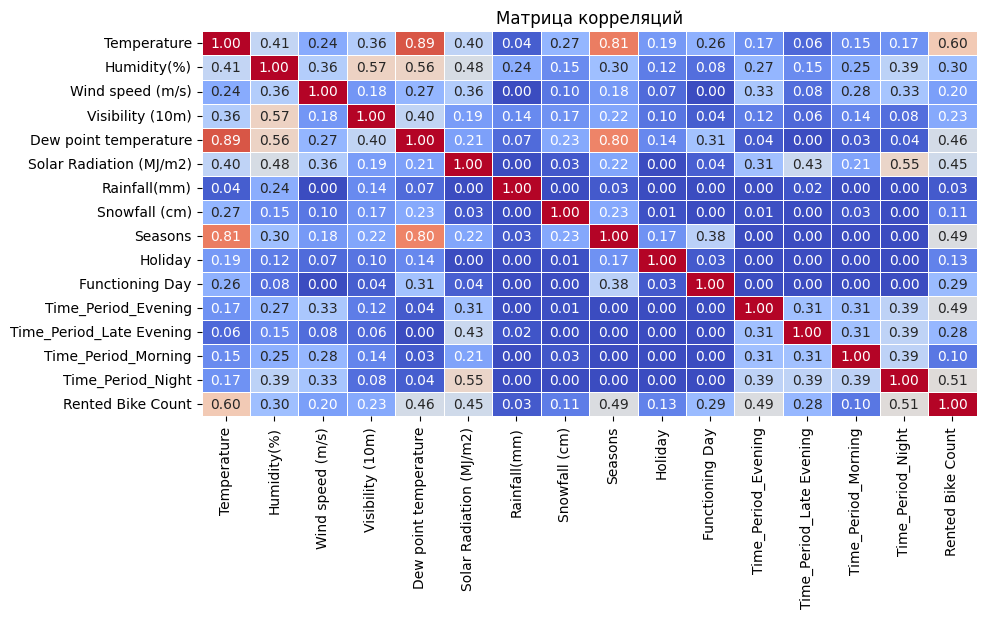

In [33]:
create_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

Для KNN моделей можно проделать логарифмирование, чтобы улучшить распределение и убрать хвосты на графиках.

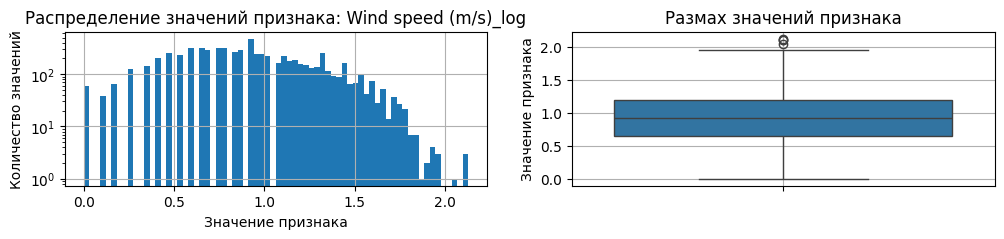

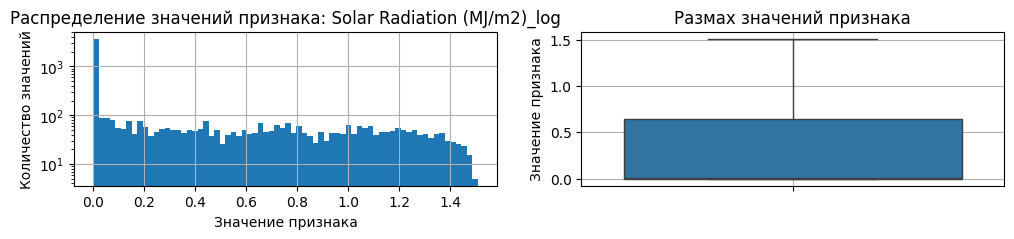

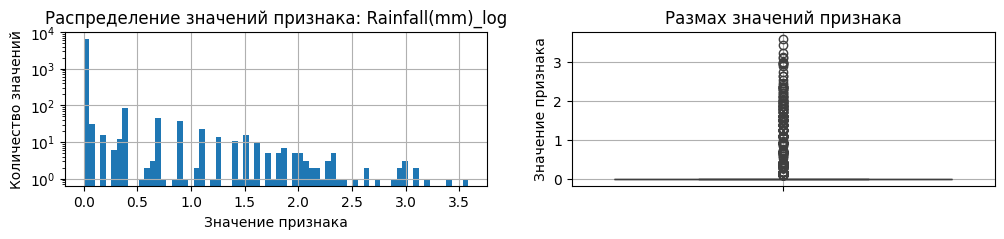

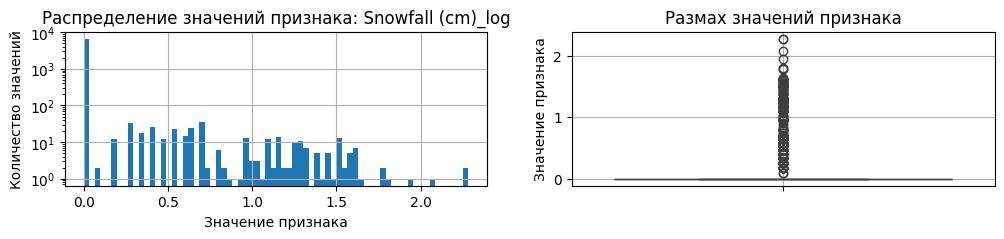

In [34]:
features_with_tails = ['Wind speed (m/s)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
log_col_names = [f'{col}_log' for col in features_with_tails]
df_eda[log_col_names] = df_eda[features_with_tails].apply(np.log1p)

for col in log_col_names:
    create_df_hist(df_eda[col], col)

Для признаков Rainfall и Snowfall логарифмирование не улучшило распределение - удалим признаки _log, но признаки стоит доработать, чтобы модели было проще работать с ними. Стоит преобразовать в категории.

In [35]:
df_eda = df_eda.drop(columns=['Rainfall(mm)_log', 'Snowfall (cm)_log', 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'])

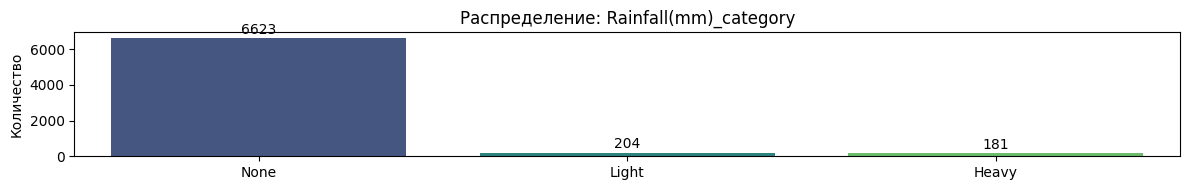

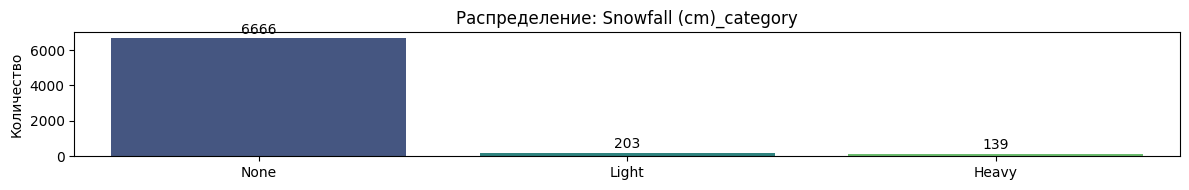

In [36]:
for col in ['Rainfall(mm)', 'Snowfall (cm)']:
    new_col = f"{col}_category"

    df_eda[new_col] = pd.cut(df_eda[col], 
                             bins=[-np.inf, 0, 1, np.inf], 
                             labels=['None', 'Light', 'Heavy'])
    
    df_eda = df_eda.drop(columns=[col])
    
    show_countplot(df_eda, new_col)

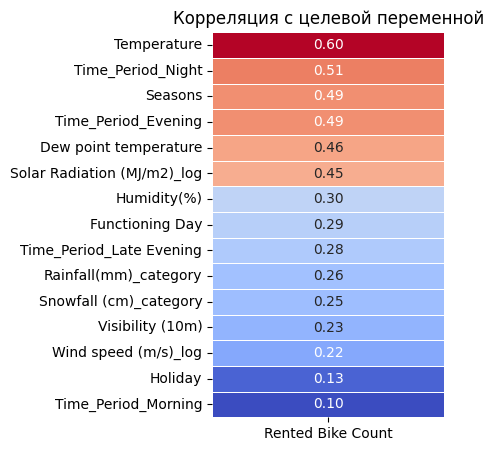

In [37]:
corr_matrix = df_eda.phik_matrix(njobs=4, interval_cols=['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rented Bike Count', 'Wind speed (m/s)_log', 'Solar Radiation (MJ/m2)_log'])
target_corr = corr_matrix[corr_matrix.index != 'Rented Bike Count'][['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

create_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

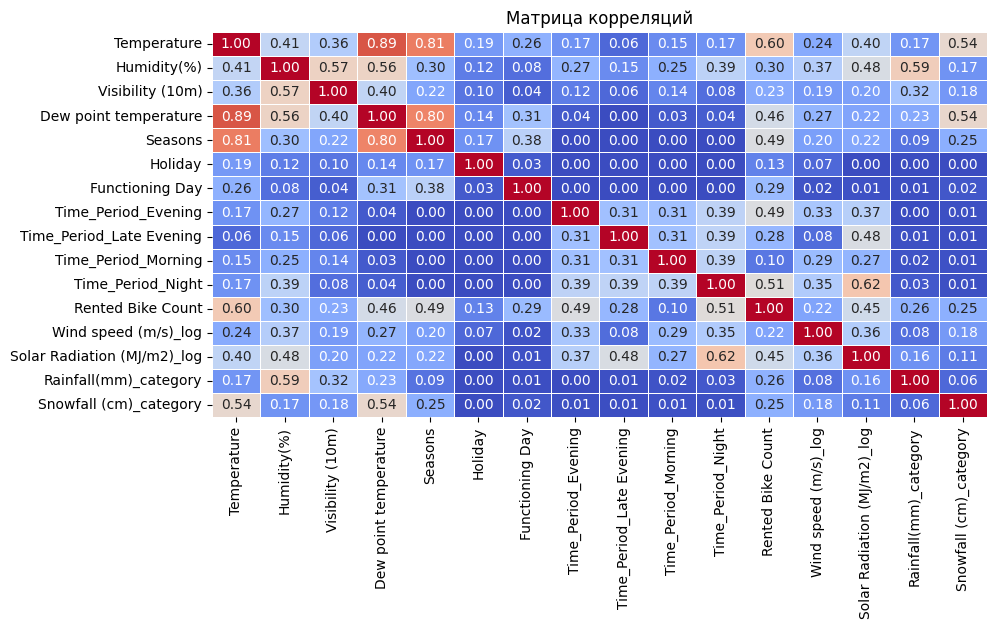

In [38]:
create_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

Для KNN важно избавиться от корреляции между признаками, поэтому данные столбцы не будут удалены сразу, а только при обучении моделей KNN. Оставить стоит только Temperature, так как данный признак имеет наибольшую корреляция с таргетом. Удаляться будут: 'Seasons', 'Dew point temperature'.

---

**Шаг 2. Разделение данных на тренировочную и валидационную выборки**

Используйте на этом этапе данные файла `ds_s14_train_data.csv`. Тестовый набор нужен только для финальной оценки модели после обучения и подбора гиперпараметров.

Подготовка данных вам понадобится, чтобы обучить модель и оценить её качество через валидацию.

---

In [39]:
target = ['Rented Bike Count']
correlating_features = ['Seasons', 'Dew point temperature']

log_features = ['Wind speed (m/s)', 'Solar Radiation (MJ/m2)']
fall_features = ['Rainfall(mm)', 'Snowfall (cm)']

In [40]:
num_cols = [col for col in num_cols if col not in correlating_features]
cat_cols = [col for col in cat_cols if col not in correlating_features]
bool_cols = [col for col in bool_cols if col not in correlating_features]

In [41]:
knn_num_cols = num_cols = [col for col in num_cols if col not in log_features + fall_features + target]

In [42]:
def bool_to_int(df):
    return df.astype(int)

In [43]:
def fall_binning(X):
    X_df = X.copy()
    for col in X_df.columns:
        X_df[col] = pd.cut(
            X_df[col], 
            bins=[-np.inf, 0, 1, np.inf], 
            labels=['None', 'Light', 'Heavy'],
        )
    return X_df

def get_fall_feature_names(transformer, input_features):
    return input_features 

knn_preprocessor = ColumnTransformer(
    transformers=[
        ('log', make_pipeline(
                SimpleImputer(strategy='constant', fill_value=0),
                FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                StandardScaler()
        ), log_features),
        
        ('num', make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler()
        ), knn_num_cols),
        
        ('fall', make_pipeline(
            FunctionTransformer(fall_binning, feature_names_out=get_fall_feature_names),
            OneHotEncoder(drop='first', sparse_output=False),
        ), fall_features),
        
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        
        ('bool', FunctionTransformer(bool_to_int, feature_names_out="one-to-one"), bool_cols)
    ],
    remainder='drop'
).set_output(transform="pandas")

In [44]:
X_transformed_df = knn_preprocessor.fit_transform(X_train_val)
X_transformed_df.head()

,log__Wind speed (m/s),log__Solar Radiation (MJ/m2),num__Temperature,num__Humidity(%),num__Visibility (10m),fall__Rainfall(mm)_Light,fall__Rainfall(mm)_None,fall__Rainfall(mm)_nan,fall__Snowfall (cm)_Light,fall__Snowfall (cm)_None,fall__Snowfall (cm)_nan,cat__Holiday_No Holiday,cat__Functioning Day_Yes,bool__Time_Period_Evening,bool__Time_Period_Late Evening,bool__Time_Period_Morning,bool__Time_Period_Night
1741,1.550504,-0.726497,0.527944,0.192249,0.521845,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,1,0,0
3105,0.027521,-0.726497,-0.294434,-0.307843,0.929214,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,1,0,0
1869,-0.657927,-0.726497,-1.544783,1.542495,-1.801669,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0,1,0
4643,0.219743,1.246250,0.720951,0.642331,-1.625645,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,0,0,0
387,0.310577,-0.726497,0.402070,-0.057797,-0.842759,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,0,0,1


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),KNN (baseline),340.59,233.00,0.72,33.06
1,Test,KNN (baseline),359.30,243.87,0.69,34.46


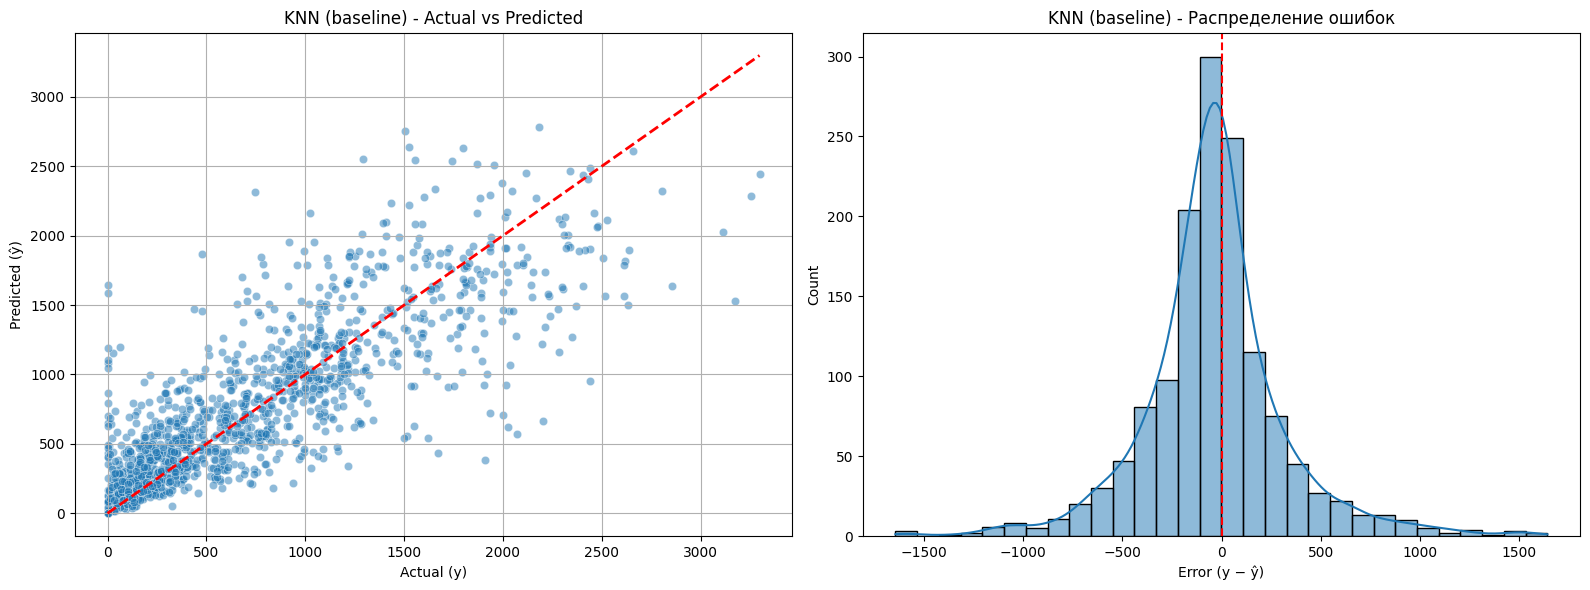

In [45]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', knn_preprocessor),
    ('model', KNeighborsRegressor())
])

knn_baseline_metrics_df = show_metrics('KNN (baseline)', knn_pipeline)

,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),KNN (filted),327.06,219.1,0.74,31.08
1,Test,KNN (filted),334.61,222.3,0.73,31.41


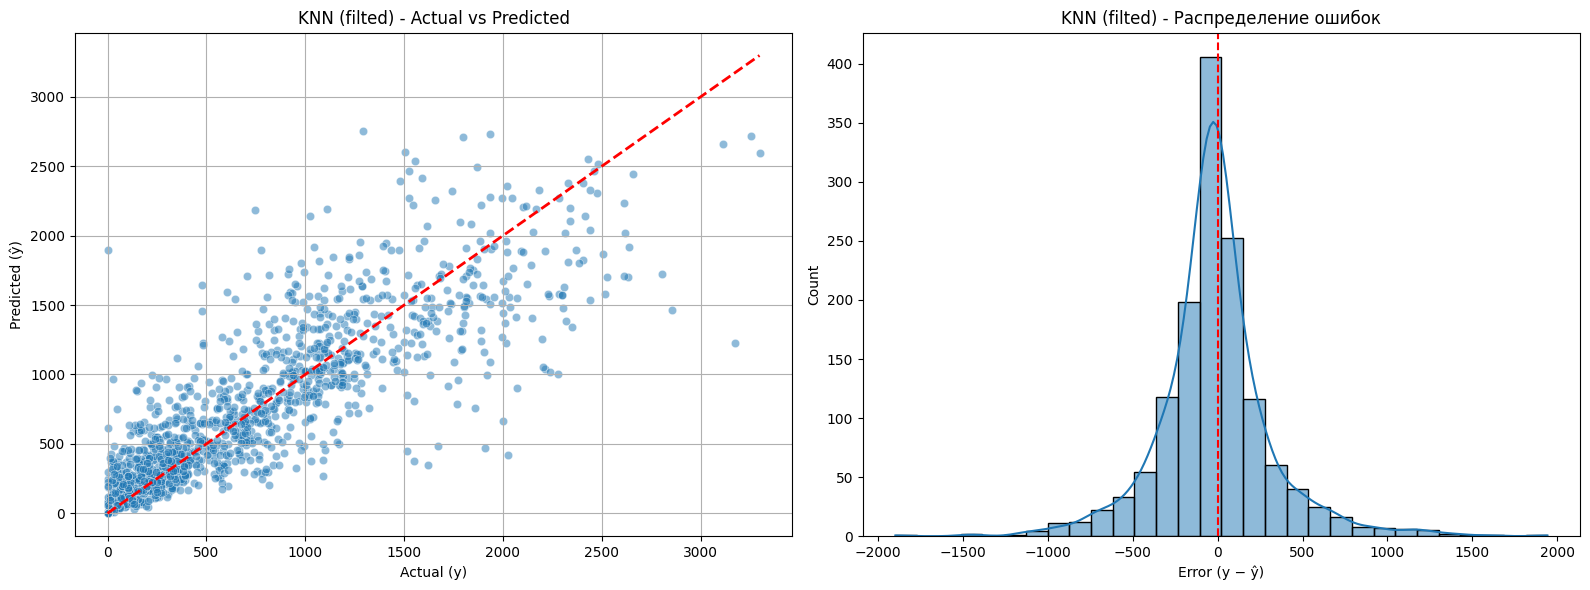

In [46]:
rf_estimator = Ridge(random_state=RANDOM_STATE)

knn_pipeline = Pipeline(steps=[
    ('preprocessor', knn_preprocessor),

    ('var_thresh', VarianceThreshold(threshold=0.001)),
    ('correlation_filter', SelectKBest(score_func=f_regression, k='all')),
    ('rfe', RFE(estimator=rf_estimator, n_features_to_select=.8, step=2)),

    ('model', KNeighborsRegressor())
])

knn_filted_metrics_df = show_metrics('KNN (filted)', knn_pipeline)

In [47]:
def objective(trial):
    params = {
        "n_neighbors": trial.suggest_int('n_neighbors', 2, 40),
        "weights": trial.suggest_categorical('weights', ['uniform', 'distance']),
        "p": trial.suggest_int('p', 1, 4)
    }

    model = KNeighborsRegressor(**params)
    pipeline = Pipeline([
        ("preprocessor", knn_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)

    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )

    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=4)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 

best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(best_value, 3))

[I 2026-02-13 10:01:23,164] A new study created in memory with name: no-name-68aebb40-b49c-4783-b331-a1fdc65eb375
Best trial: 2. Best value: 339.111:   1%|          | 1/100 [00:00<00:55,  1.78it/s]

[I 2026-02-13 10:01:23,722] Trial 2 finished with value: 339.1113876298883 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'p': 2}. Best is trial 2 with value: 339.1113876298883.


Best trial: 2. Best value: 339.111:   3%|▎         | 3/100 [00:00<00:34,  2.79it/s]

[I 2026-02-13 10:01:23,938] Trial 0 finished with value: 348.84388763462266 and parameters: {'n_neighbors': 29, 'weights': 'distance', 'p': 2}. Best is trial 2 with value: 339.1113876298883.
[I 2026-02-13 10:01:23,999] Trial 1 finished with value: 367.99045089044864 and parameters: {'n_neighbors': 31, 'weights': 'uniform', 'p': 4}. Best is trial 2 with value: 339.1113876298883.
[I 2026-02-13 10:01:24,010] Trial 3 finished with value: 370.9112562092641 and parameters: {'n_neighbors': 40, 'weights': 'uniform', 'p': 3}. Best is trial 2 with value: 339.1113876298883.


Best trial: 7. Best value: 332.225:   8%|▊         | 8/100 [00:01<00:13,  7.06it/s]

...

Best trial: 7. Best value: 332.225:  96%|█████████▌| 96/100 [00:12<00:00, 10.44it/s]

[I 2026-02-13 10:01:35,511] Trial 94 finished with value: 334.490997439756 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 2}. Best is trial 7 with value: 332.2253641515859.
[I 2026-02-13 10:01:35,566] Trial 95 finished with value: 334.490997439756 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 2}. Best is trial 7 with value: 332.2253641515859.
[I 2026-02-13 10:01:35,698] Trial 96 finished with value: 334.490997439756 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 2}. Best is trial 7 with value: 332.2253641515859.


Best trial: 7. Best value: 332.225: 100%|██████████| 100/100 [00:12<00:00,  7.89it/s]


[I 2026-02-13 10:01:35,787] Trial 97 finished with value: 334.490997439756 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 2}. Best is trial 7 with value: 332.2253641515859.
[I 2026-02-13 10:01:35,829] Trial 98 finished with value: 335.0977949177203 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 2}. Best is trial 7 with value: 332.2253641515859.
[I 2026-02-13 10:01:35,840] Trial 99 finished with value: 336.88416852275753 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 2}. Best is trial 7 with value: 332.2253641515859.


Лучшие гиперпараметры: {'n_neighbors': 15, 'weights': 'distance', 'p': 1}
Лучшее среднее значение RMSE на кросс-валидации: 332.225


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),KNN (best params),332.23,231.53,0.74,32.85
1,Test,KNN (best params),341.02,234.74,0.72,33.17


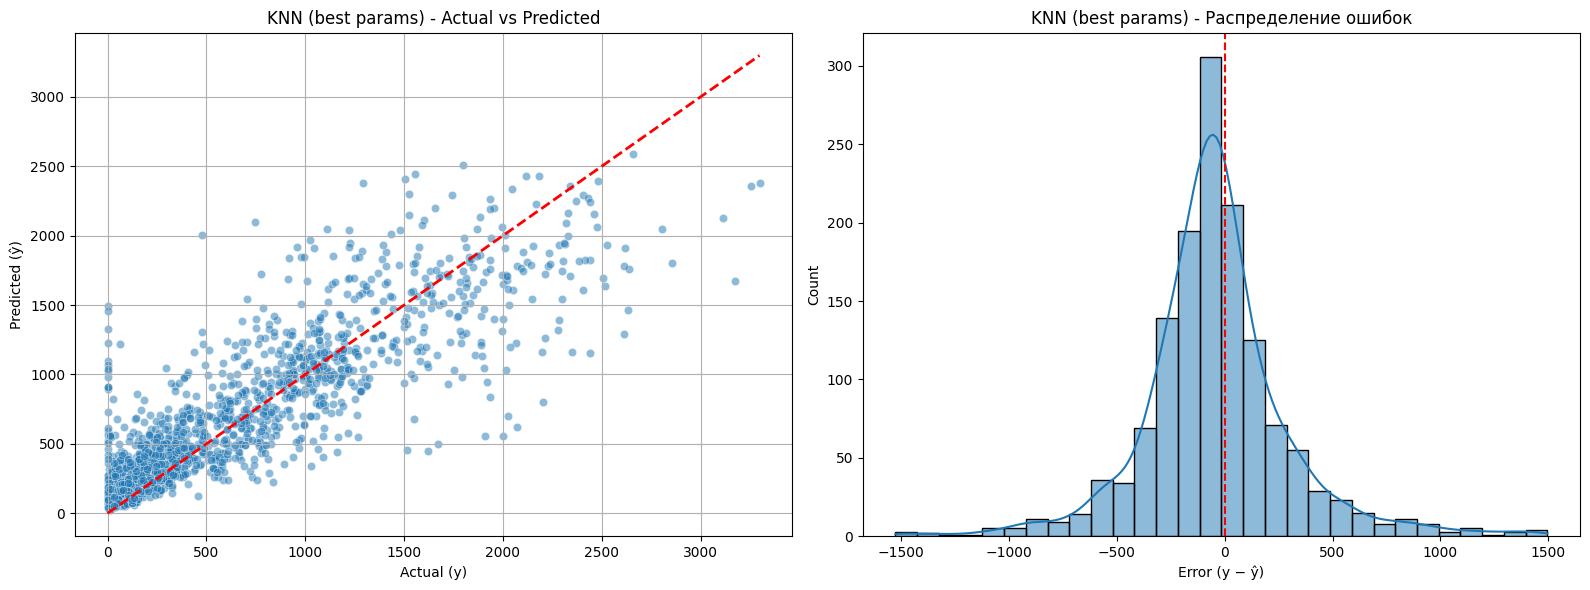

In [48]:
model = KNeighborsRegressor(**study.best_params)
knn_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("model", model)
])

knn_best_metrics_df = show_metrics('KNN (best params)', knn_pipeline)

---

In [49]:
def show_tree_plot(name, pipeline):
    tree_model = pipeline.named_steps["model"]
    preprocessor = pipeline.named_steps["preprocessor"]

    feature_names = preprocessor.get_feature_names_out()

    _, ax = plt.subplots(1, 1, figsize=(26, 12))
    plot_tree(
        tree_model,
        ax=ax,
        filled=True,
        rounded=True,
        feature_names=feature_names,
        fontsize=12,
        max_depth=3,
        impurity=False,
        precision=2 
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

In [50]:
def show_feature_importance(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    feature_importance = pd.DataFrame(
        {
            "feature": preprocessor.get_feature_names_out(),
            "importance": model.feature_importances_ * 100,
        }
    ).sort_values("importance", ascending=False)

    display(feature_importance \
            .style.format({'importance': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm'))
    
    top_5_feature_names = feature_importance['feature'].values[:5]
    top_5_feature_importance = feature_importance['importance'].values[:5]

    plt.figure(figsize=(8, 5))
    plt.barh(top_5_feature_names, top_5_feature_importance, color='lightseagreen')
    plt.xlabel('Важность признака')
    plt.title('Важность признаков в дереве решений')
    plt.gca().invert_yaxis()
    plt.grid()
    plt.show()

In [51]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        ('bool', FunctionTransformer(bool_to_int, feature_names_out="one-to-one"), bool_cols)
    ],
    remainder='drop'
).set_output(transform="pandas")

In [52]:
X_transformed_df = tree_preprocessor.fit_transform(X_train_val)
X_transformed_df.head()

,num__Temperature,num__Humidity(%),num__Visibility (10m),cat__Holiday_No Holiday,cat__Functioning Day_Yes,bool__Time_Period_Evening,bool__Time_Period_Late Evening,bool__Time_Period_Morning,bool__Time_Period_Night
1741,19.1,62.0,1757.0,1.0,1.0,0,1,0,0
3105,9.3,52.0,2000.0,1.0,1.0,0,1,0,0
1869,-5.6,89.0,371.0,1.0,1.0,0,0,1,0
4643,21.4,71.0,476.0,1.0,1.0,0,0,0,0
387,17.6,57.0,943.0,1.0,1.0,0,0,0,1


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Decision Tree Regressor (baseline),447.61,286.84,0.52,40.70
1,Test,Decision Tree Regressor (baseline),453.32,288.41,0.50,40.76


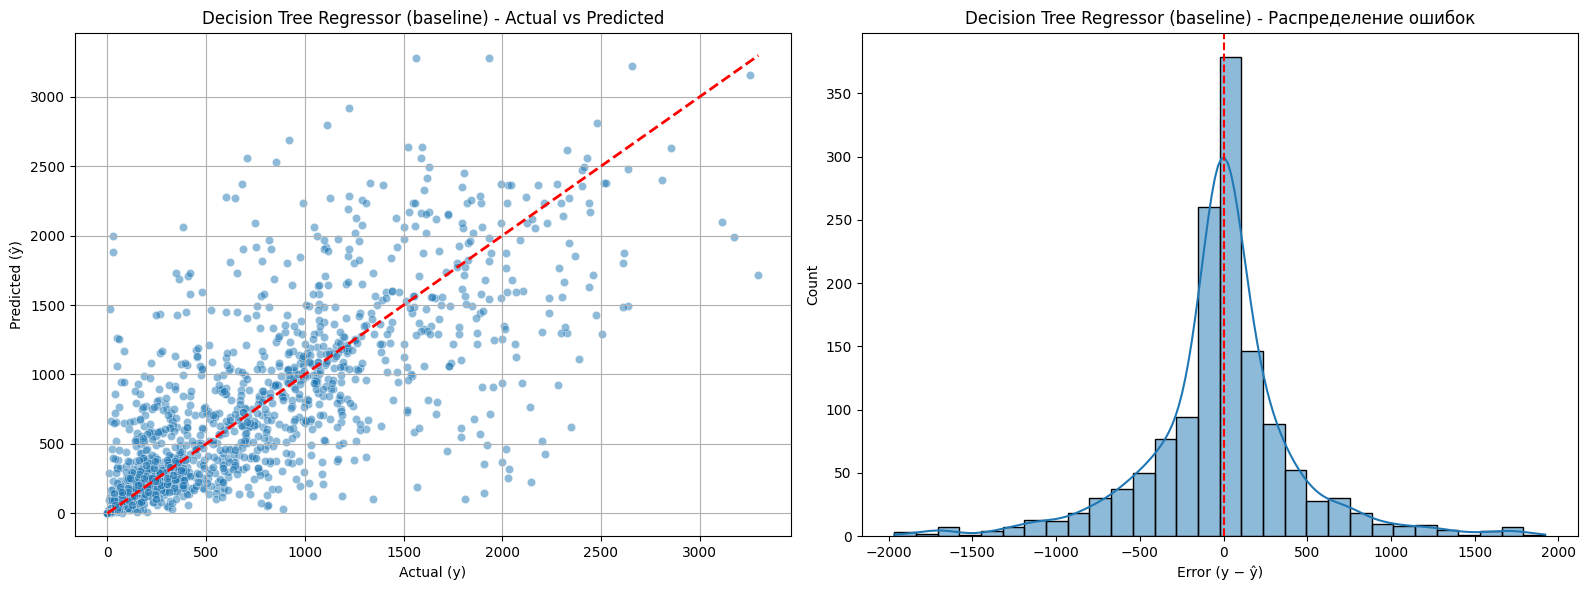

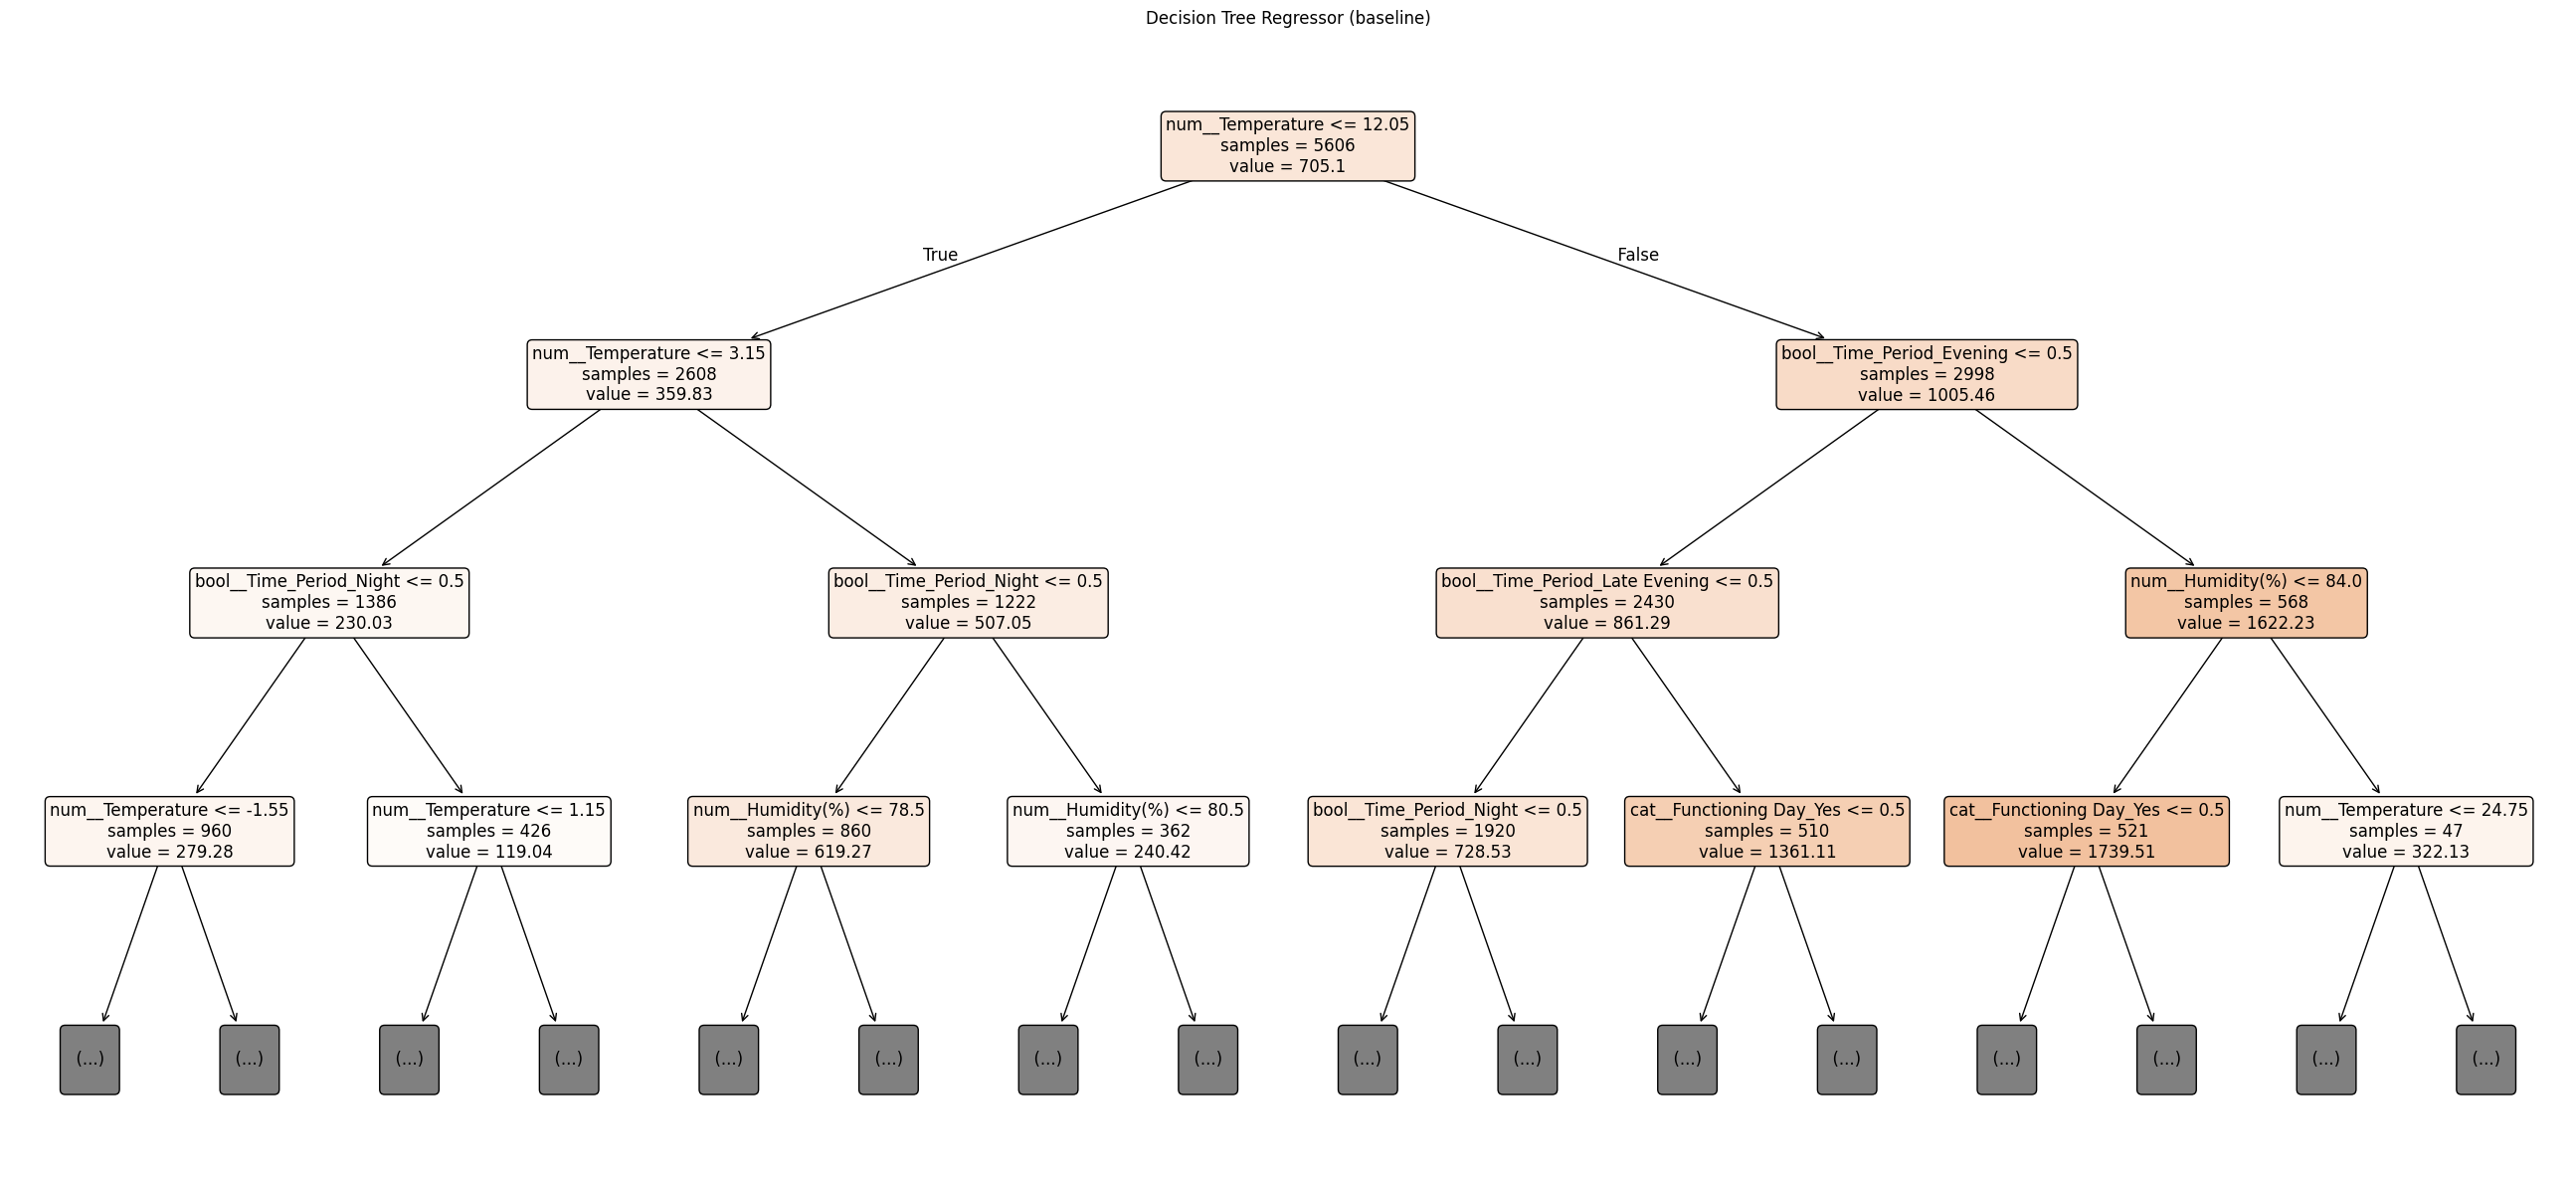

,feature,importance
0,num__Temperature,39.77%
1,num__Humidity(%),17.84%
5,bool__Time_Period_Evening,11.58%
4,cat__Functioning Day_Yes,8.81%
2,num__Visibility (10m),8.30%
6,bool__Time_Period_Late Evening,7.01%
8,bool__Time_Period_Night,5.38%
7,bool__Time_Period_Morning,0.90%
3,cat__Holiday_No Holiday,0.40%


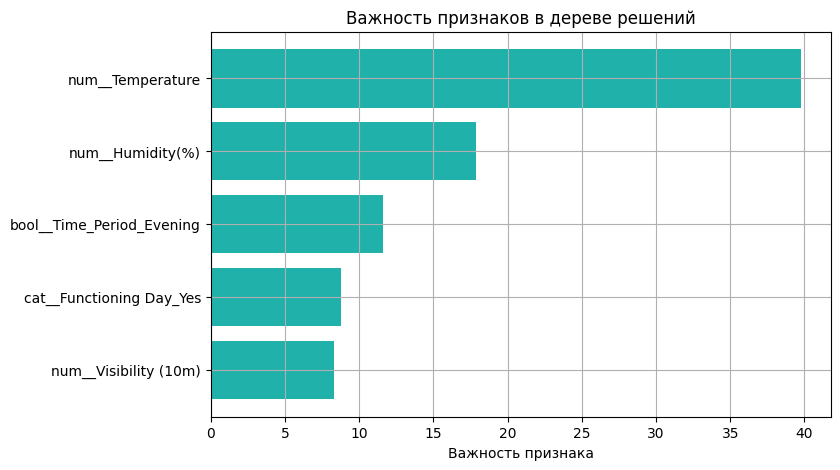

In [53]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

name = 'Decision Tree Regressor (baseline)'
dtr_baseline_metrics_df = show_metrics(name, tree_pipeline)
show_tree_plot(name, tree_pipeline)
show_feature_importance(tree_pipeline)

In [54]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 32),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 2, 100),  
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.1),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error"])
    }

    model = DecisionTreeRegressor(**params, random_state=RANDOM_STATE)
    pipeline = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)
    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )

    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=4)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 

best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(best_value, 3))

[I 2026-02-13 10:01:36,735] A new study created in memory with name: no-name-c2fe35b8-40bd-4f4d-8045-2f079532bf22
Best trial: 3. Best value: 349.381:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-13 10:01:36,807] Trial 3 finished with value: 349.380546755203 and parameters: {'max_depth': 31, 'min_samples_split': 6, 'min_samples_leaf': 15, 'max_leaf_nodes': 25, 'ccp_alpha': 0.06710001020399038, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 3 with value: 349.380546755203.


Best trial: 3. Best value: 349.381:   2%|▏         | 2/100 [00:00<00:22,  4.41it/s]

[I 2026-02-13 10:01:37,189] Trial 2 finished with value: 465.734158414567 and parameters: {'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 5, 'max_leaf_nodes': 56, 'ccp_alpha': 0.05290947030503265, 'max_features': 'sqrt', 'criterion': 'absolute_error'}. Best is trial 3 with value: 349.380546755203.
[I 2026-02-13 10:01:37,197] Trial 0 finished with value: 404.33126682789407 and parameters: {'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 13, 'max_leaf_nodes': 80, 'ccp_alpha': 0.05251883889159218, 'max_features': 'sqrt', 'criterion': 'absolute_error'}. Best is trial 3 with value: 349.380546755203.


Best trial: 4. Best value: 348.347:   8%|▊         | 8/100 [00:00<00:08, 10.88it/s]

...

Best trial: 85. Best value: 341.857:  97%|█████████▋| 97/100 [00:11<00:00, 23.06it/s]

[I 2026-02-13 10:01:47,942] Trial 92 finished with value: 343.90183537807536 and parameters: {'max_depth': 21, 'min_samples_split': 12, 'min_samples_leaf': 15, 'max_leaf_nodes': 86, 'ccp_alpha': 0.010497639468760513, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 85 with value: 341.8565057811391.
[I 2026-02-13 10:01:47,951] Trial 93 finished with value: 448.97103673854235 and parameters: {'max_depth': 21, 'min_samples_split': 12, 'min_samples_leaf': 18, 'max_leaf_nodes': 86, 'ccp_alpha': 0.010800224494800621, 'max_features': 'log2', 'criterion': 'squared_error'}. Best is trial 85 with value: 341.8565057811391.
[I 2026-02-13 10:01:48,013] Trial 94 finished with value: 347.0038208390517 and parameters: {'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 18, 'max_leaf_nodes': 86, 'ccp_alpha': 0.009637334175797634, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 85 with value: 341.8565057811391.
[I 2026-02-13 10:01:48,041] Trial 95 finished 

Best trial: 85. Best value: 341.857: 100%|██████████| 100/100 [00:11<00:00,  8.73it/s]


[I 2026-02-13 10:01:48,173] Trial 98 finished with value: 342.7369936501197 and parameters: {'max_depth': 25, 'min_samples_split': 8, 'min_samples_leaf': 16, 'max_leaf_nodes': 98, 'ccp_alpha': 0.019825841524571206, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 85 with value: 341.8565057811391.
[I 2026-02-13 10:01:48,184] Trial 99 finished with value: 342.8562090392035 and parameters: {'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 16, 'max_leaf_nodes': 91, 'ccp_alpha': 0.01869645250836755, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 85 with value: 341.8565057811391.


Лучшие гиперпараметры: {'max_depth': 23, 'min_samples_split': 12, 'min_samples_leaf': 17, 'max_leaf_nodes': 99, 'ccp_alpha': 0.0008811062152447452, 'max_features': None, 'criterion': 'squared_error'}
Лучшее среднее значение RMSE на кросс-валидации: 341.857


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Decision Tree Regressor (best params),341.86,230.24,0.72,32.67
1,Test,Decision Tree Regressor (best params),352.36,241.24,0.70,34.09


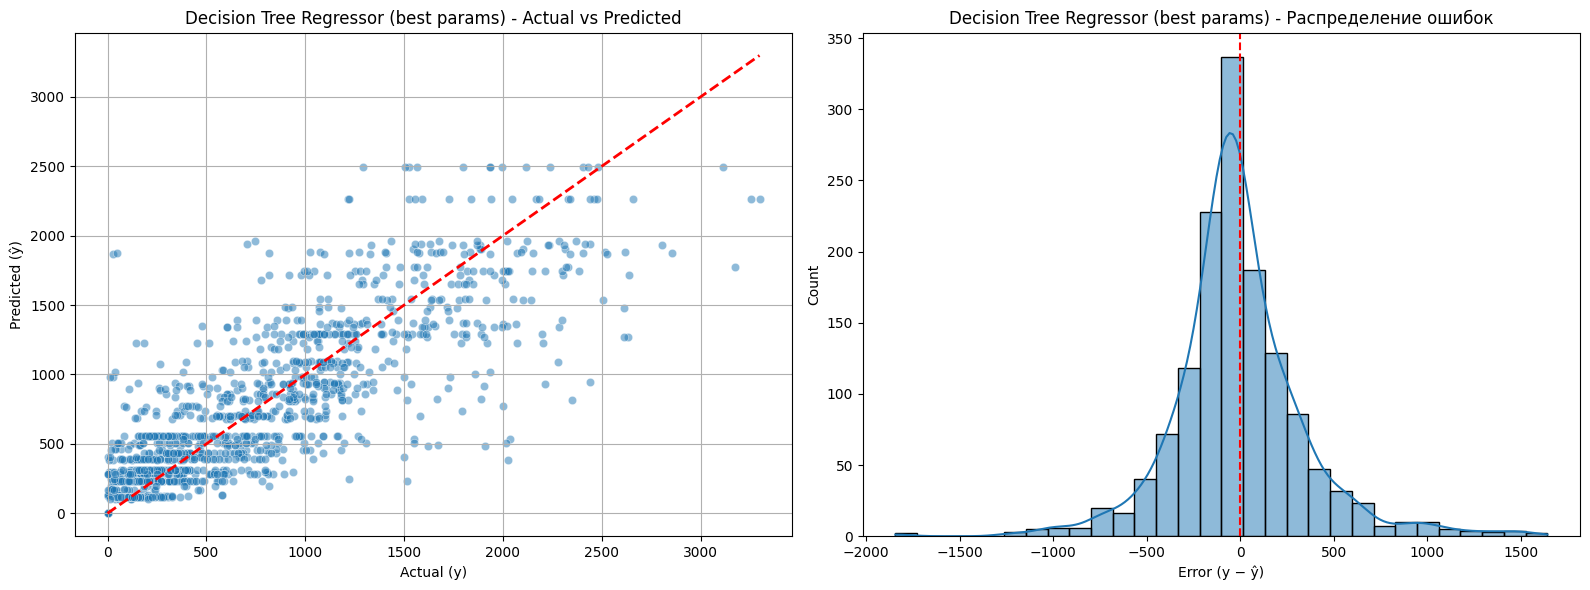

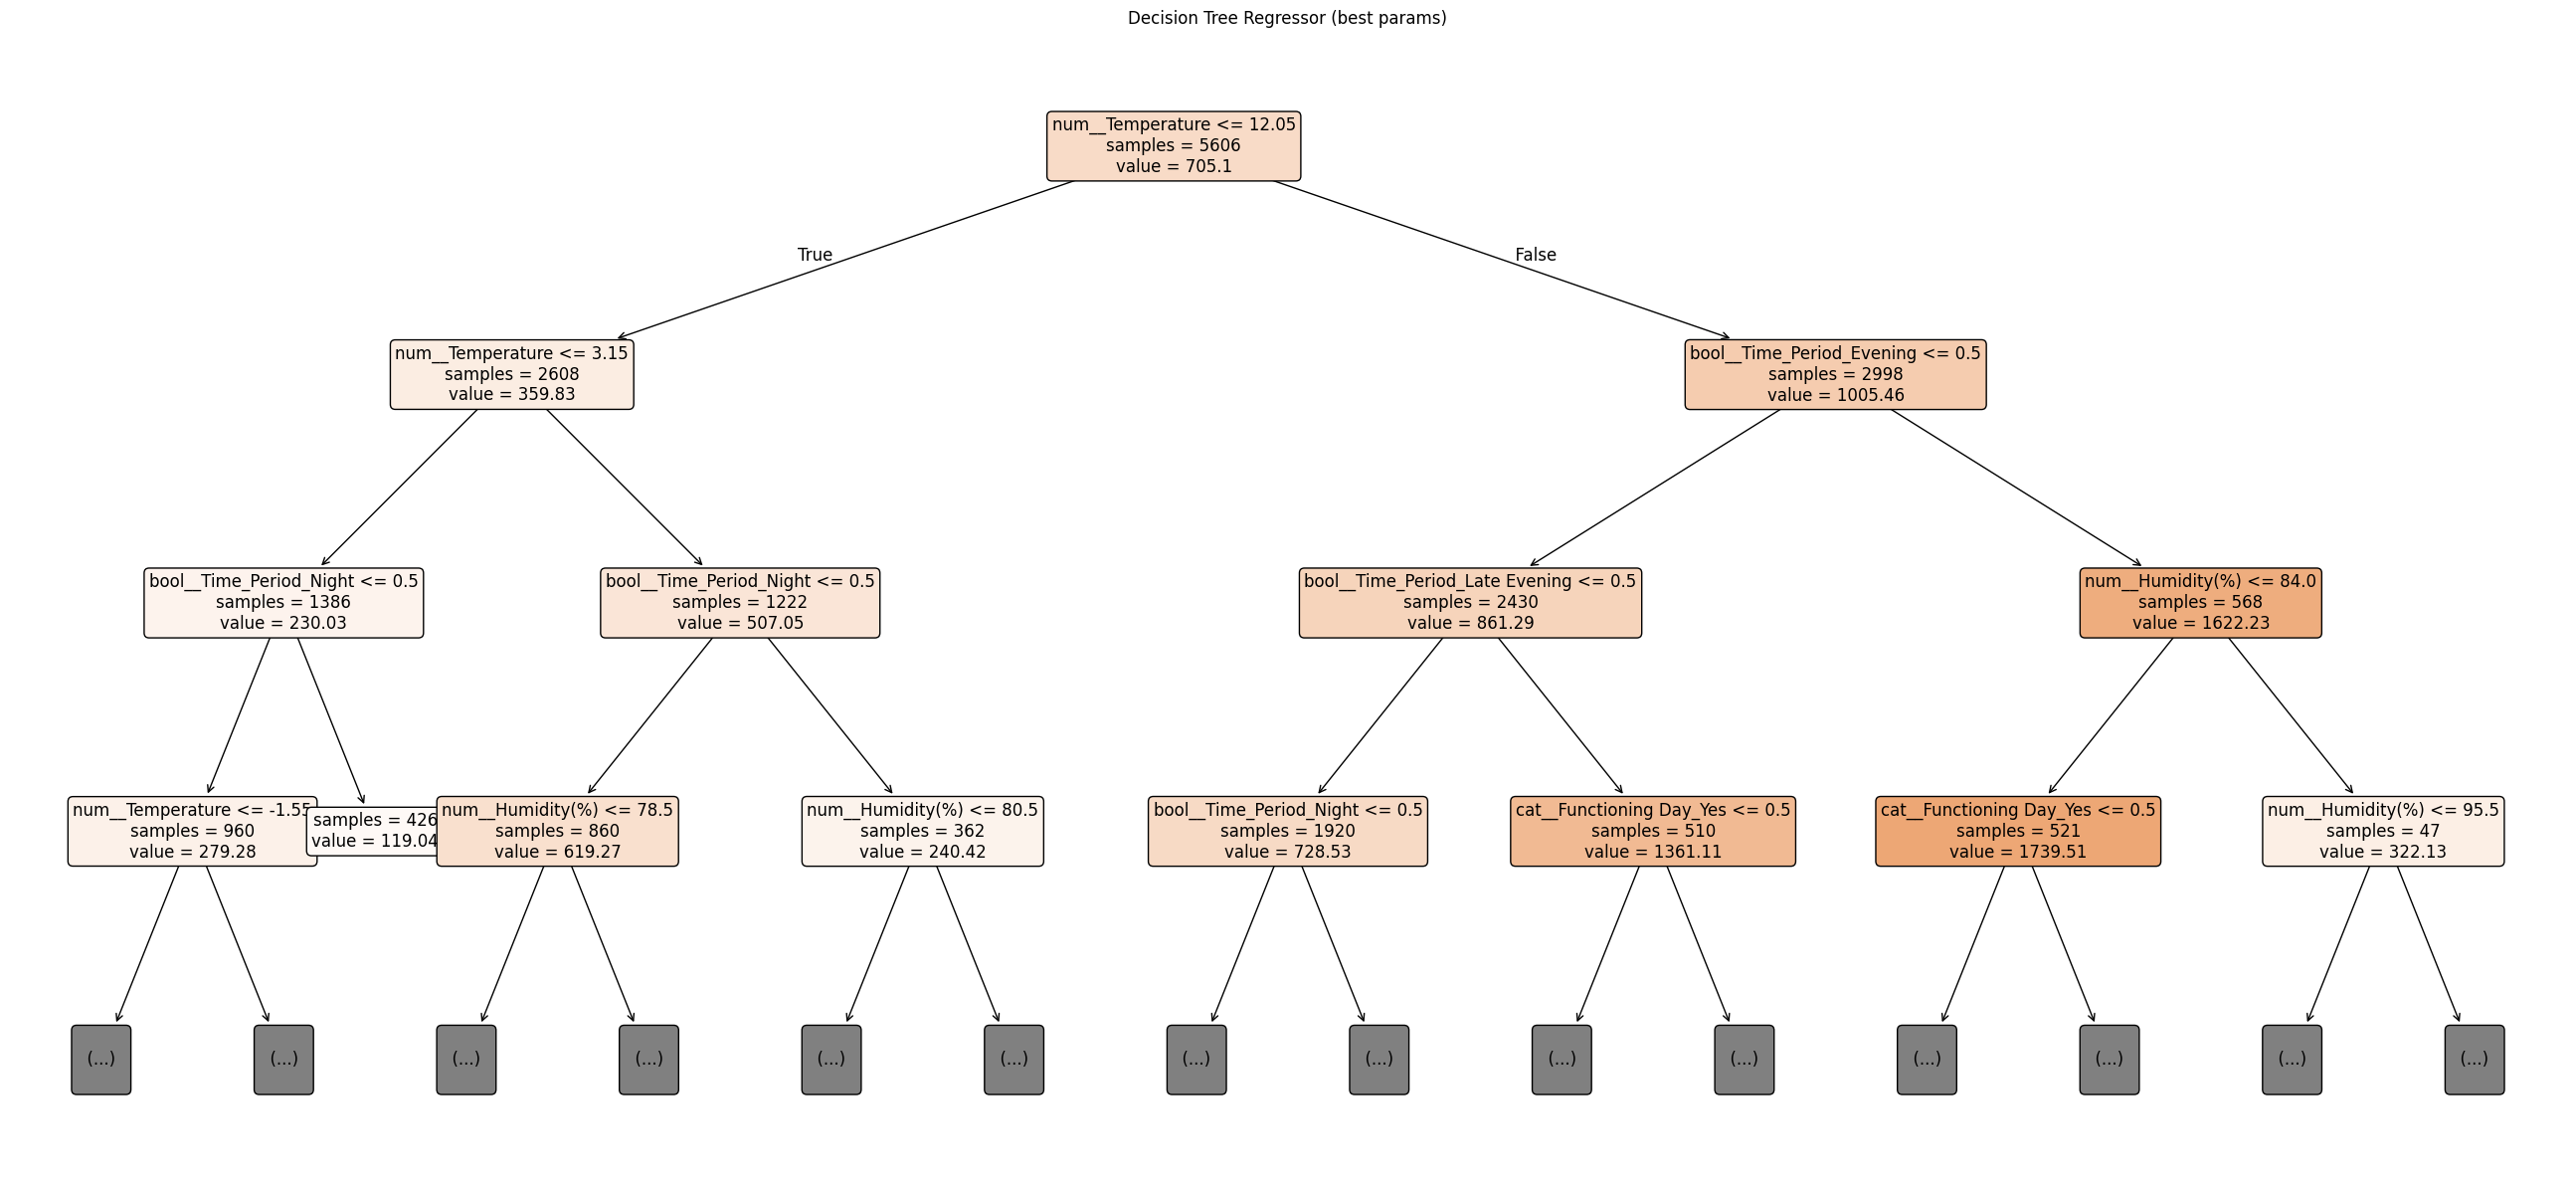

,feature,importance
0,num__Temperature,41.68%
5,bool__Time_Period_Evening,14.60%
1,num__Humidity(%),14.51%
4,cat__Functioning Day_Yes,11.14%
6,bool__Time_Period_Late Evening,8.88%
8,bool__Time_Period_Night,6.88%
2,num__Visibility (10m),1.71%
7,bool__Time_Period_Morning,0.60%
3,cat__Holiday_No Holiday,0.00%


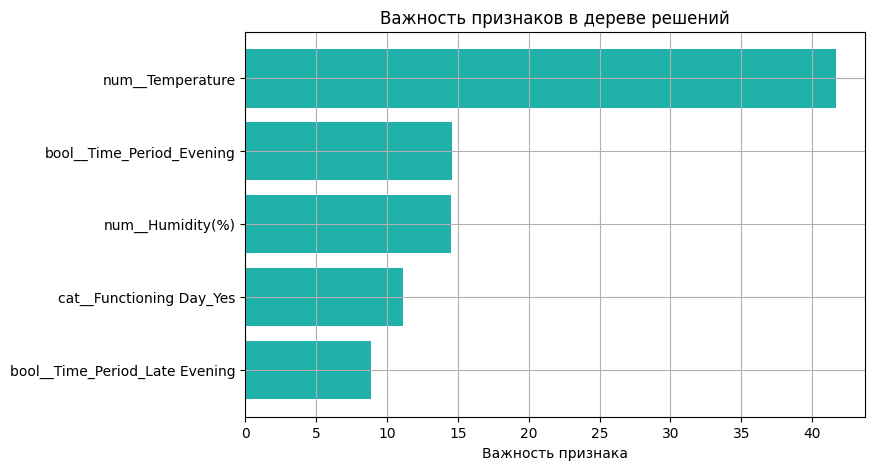

In [55]:
model = DecisionTreeRegressor(**study.best_params)
tree_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", model)
])

name = 'Decision Tree Regressor (best params)'
dtr_best_metrics_df = show_metrics(name, tree_pipeline)
show_tree_plot(name, tree_pipeline)
show_feature_importance(tree_pipeline)

,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Random Forest Regressor (baseline),330.89,217.49,0.74,30.86
1,Test,Random Forest Regressor (baseline),341.88,225.35,0.72,31.85


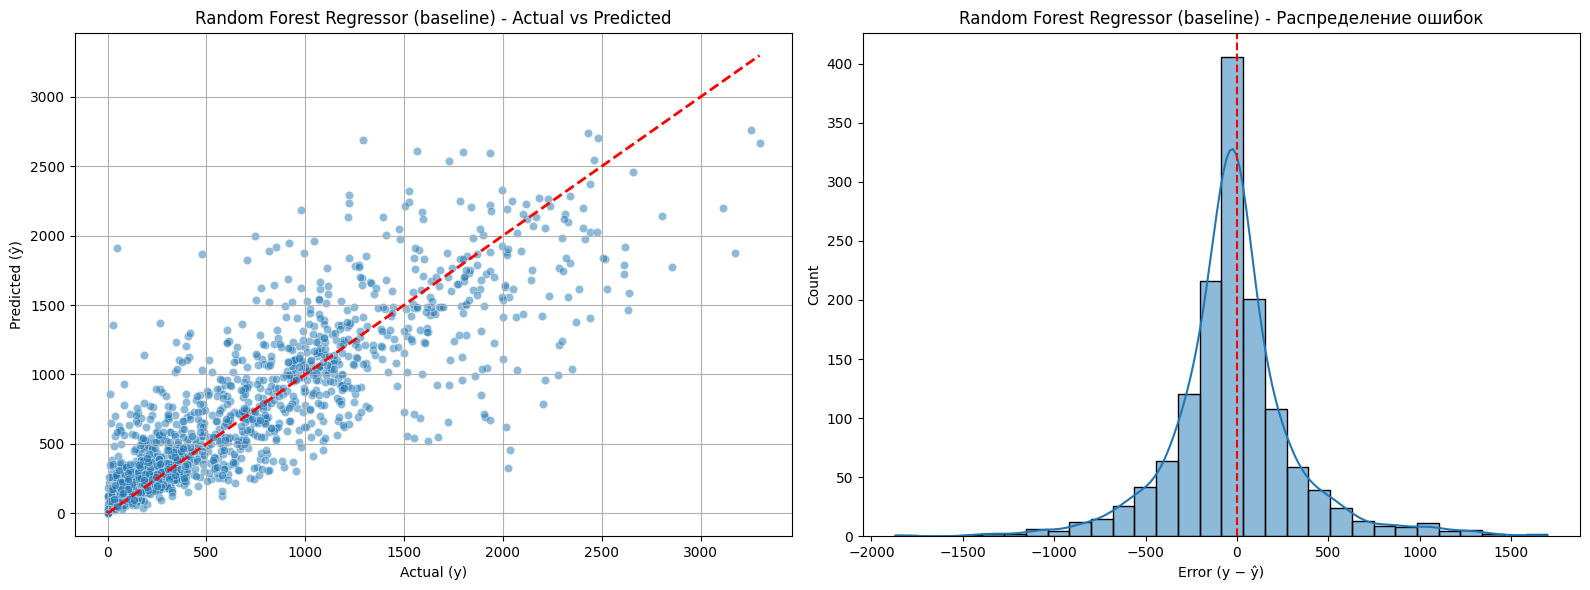

,feature,importance
0,num__Temperature,40.48%
1,num__Humidity(%),17.64%
5,bool__Time_Period_Evening,9.90%
8,bool__Time_Period_Night,9.09%
4,cat__Functioning Day_Yes,8.32%
2,num__Visibility (10m),7.83%
6,bool__Time_Period_Late Evening,5.36%
7,bool__Time_Period_Morning,0.92%
3,cat__Holiday_No Holiday,0.46%


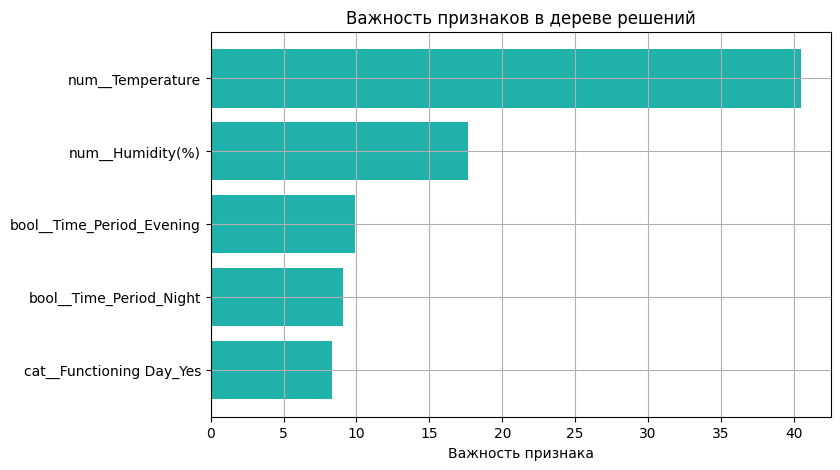

In [56]:
bagging_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))
])

rfr_baseline_metrics_df = show_metrics('Random Forest Regressor (baseline)', bagging_pipeline)
show_feature_importance(bagging_pipeline)

In [57]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 5, 35),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 0.1, log=True),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "friedman_mse"]) 
    }

    model = RandomForestRegressor(**params, random_state=RANDOM_STATE)
    pipeline = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)
    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )

    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=20, show_progress_bar=True, n_jobs=4)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 

best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(best_value, 3))

[I 2026-02-13 10:01:50,366] A new study created in memory with name: no-name-e9f2e9f4-6664-4f56-afc6-569a86d4db75
Best trial: 1. Best value: 341.55:   5%|▌         | 1/20 [00:02<00:52,  2.75s/it]

[I 2026-02-13 10:01:53,116] Trial 1 finished with value: 341.54977701350646 and parameters: {'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True, 'ccp_alpha': 0.030219174779960244, 'criterion': 'squared_error'}. Best is trial 1 with value: 341.54977701350646.


Best trial: 1. Best value: 341.55:  10%|█         | 2/20 [00:03<00:26,  1.46s/it]

[I 2026-02-13 10:01:53,670] Trial 2 finished with value: 345.40410631707726 and parameters: {'n_estimators': 350, 'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'ccp_alpha': 0.0698641724138665, 'criterion': 'squared_error'}. Best is trial 1 with value: 341.54977701350646.


Best trial: 0. Best value: 320.255:  15%|█▌        | 3/20 [00:05<00:33,  1.98s/it]

...

Best trial: 15. Best value: 319.119:  90%|█████████ | 18/20 [00:17<00:01,  1.75it/s]

[I 2026-02-13 10:02:07,752] Trial 17 finished with value: 320.665469026652 and parameters: {'n_estimators': 100, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'ccp_alpha': 0.0019582644320266583, 'criterion': 'squared_error'}. Best is trial 15 with value: 319.11916395765655.
[I 2026-02-13 10:02:07,814] Trial 18 finished with value: 320.48688499853114 and parameters: {'n_estimators': 100, 'max_depth': 35, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'ccp_alpha': 0.002387080940248779, 'criterion': 'squared_error'}. Best is trial 15 with value: 319.11916395765655.


Best trial: 15. Best value: 319.119: 100%|██████████| 20/20 [00:18<00:00,  1.09it/s]

[I 2026-02-13 10:02:08,708] Trial 19 finished with value: 320.5259131294407 and parameters: {'n_estimators': 150, 'max_depth': 34, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'ccp_alpha': 0.0021506004197102183, 'criterion': 'squared_error'}. Best is trial 15 with value: 319.11916395765655.


Лучшие гиперпараметры: {'n_estimators': 100, 'max_depth': 34, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'ccp_alpha': 0.003280487597897261, 'criterion': 'squared_error'}
Лучшее среднее значение RMSE на кросс-валидации: 319.119


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Random Forest Regressor (best params),319.26,213.97,0.76,30.36
1,Test,Random Forest Regressor (best params),331.97,222.42,0.73,31.43


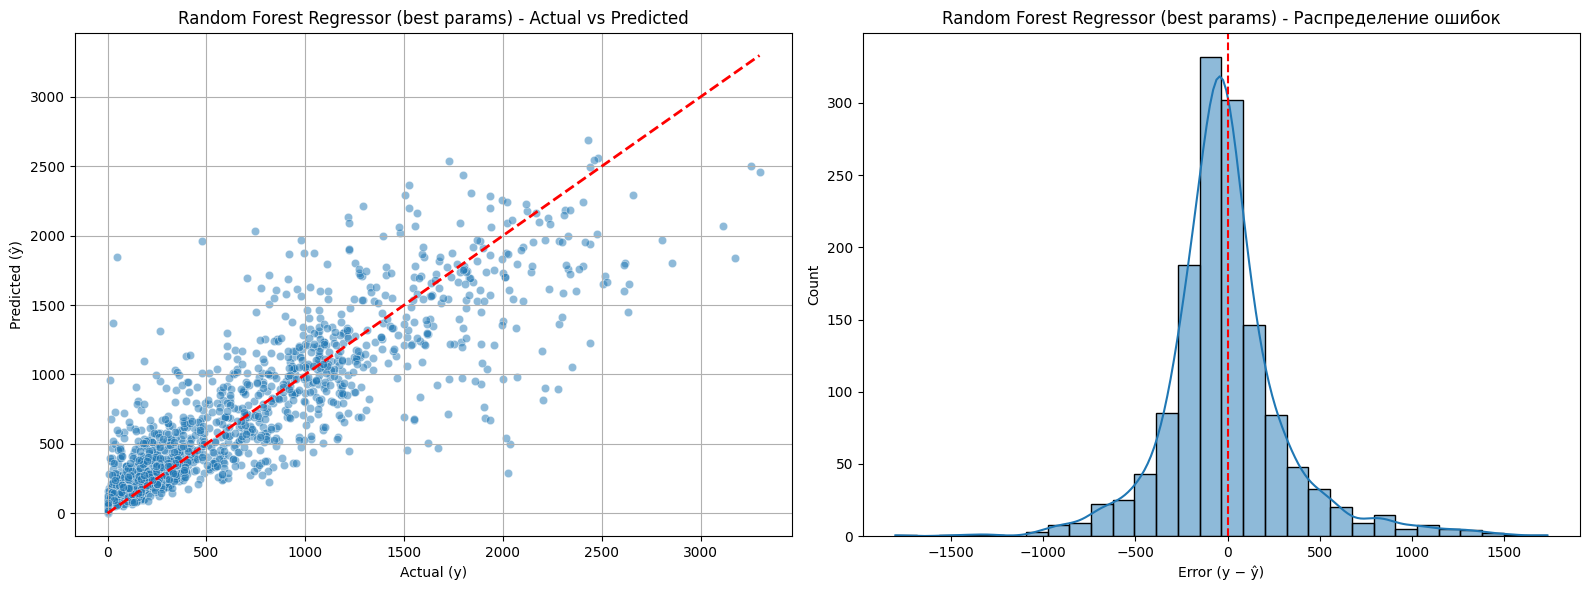

,feature,importance
0,num__Temperature,42.65%
1,num__Humidity(%),14.52%
5,bool__Time_Period_Evening,10.65%
8,bool__Time_Period_Night,10.24%
4,cat__Functioning Day_Yes,7.84%
2,num__Visibility (10m),7.74%
6,bool__Time_Period_Late Evening,4.65%
7,bool__Time_Period_Morning,1.11%
3,cat__Holiday_No Holiday,0.62%


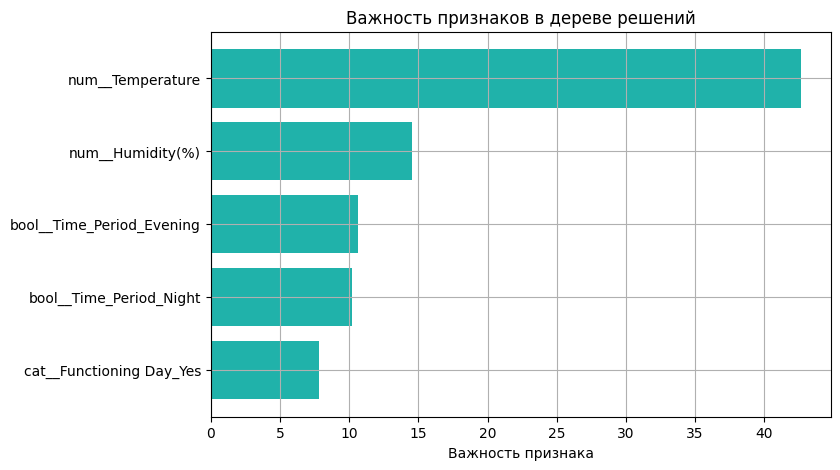

In [58]:
model = RandomForestRegressor(**study.best_params)
bagging_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", model)
])

rfr_best_metrics_df = show_metrics('Random Forest Regressor (best params)', bagging_pipeline)
show_feature_importance(bagging_pipeline)

---

,Phase,Model,RMSE,MAE,R2,WAPE%
9,Test,Decision Tree Regressor (baseline),453.32,288.41,0.50,40.76
8,Cross-Val (Mean),Decision Tree Regressor (baseline),447.61,286.84,0.52,40.70
1,Test,Linear Regression (baseline),413.56,313.12,0.59,44.25
0,Cross-Val (Mean),Linear Regression (baseline),413.41,309.72,0.59,43.94
3,Test,KNN (baseline),359.30,243.87,0.69,34.46
11,Test,Decision Tree Regressor (best params),352.36,241.24,0.70,34.09
13,Test,Random Forest Regressor (baseline),341.88,225.35,0.72,31.85
10,Cross-Val (Mean),Decision Tree Regressor (best params),341.86,230.24,0.72,32.67
7,Test,KNN (best params),341.02,234.74,0.72,33.17
2,Cross-Val (Mean),KNN (baseline),340.59,233.00,0.72,33.06


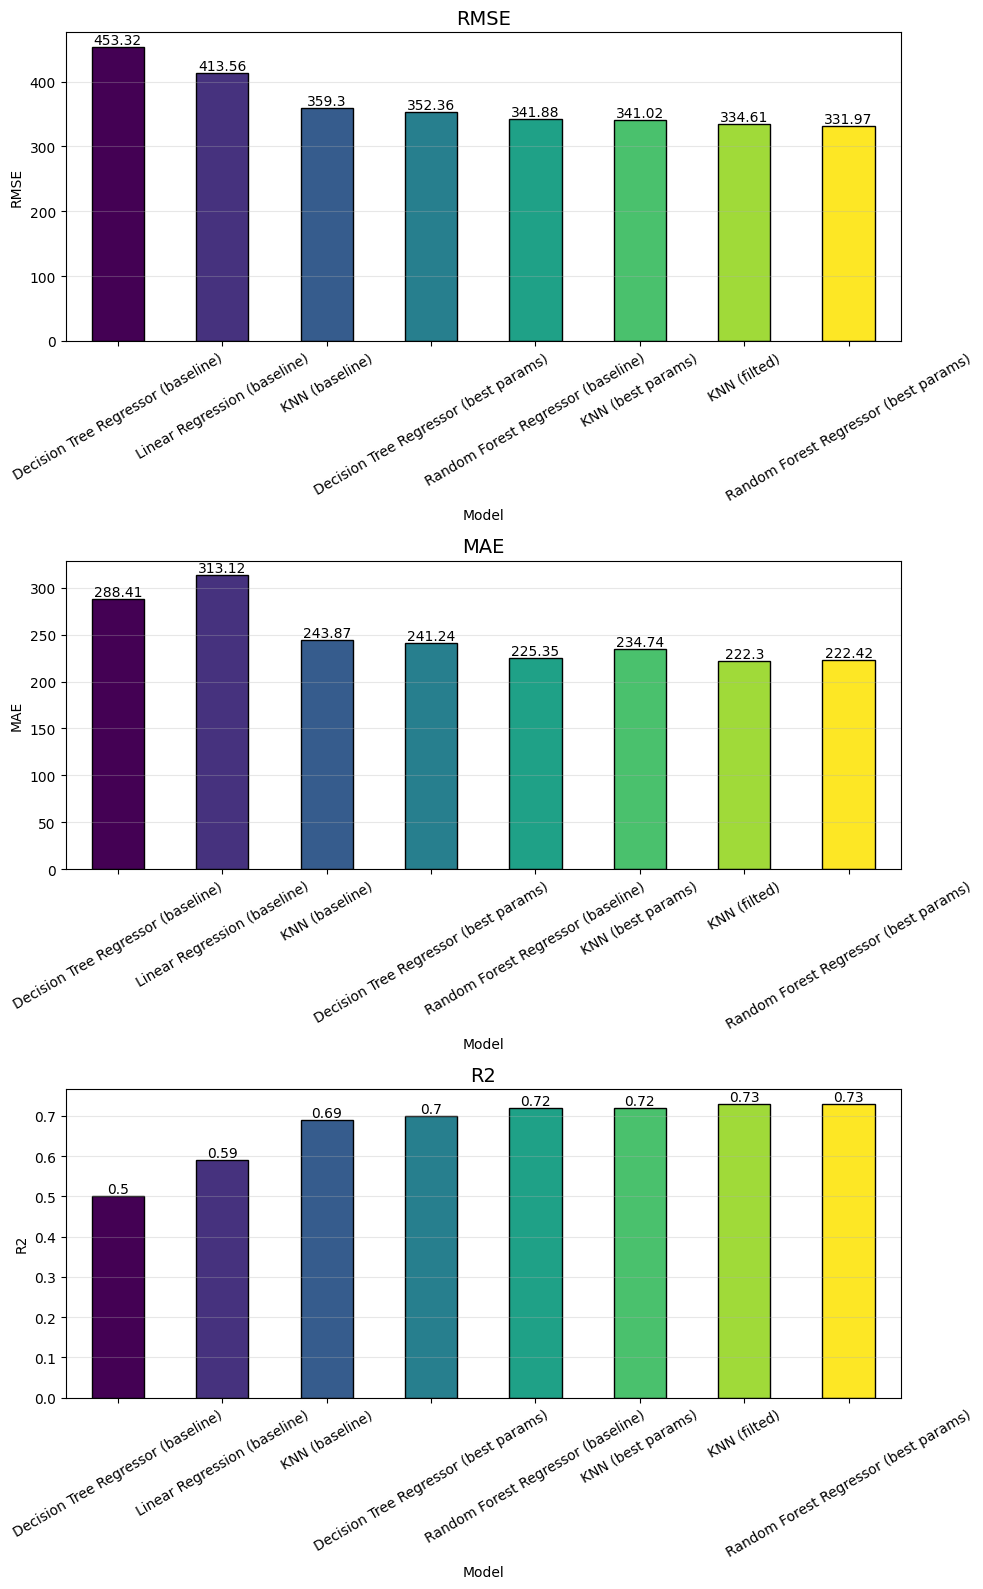

In [59]:
summary_df = pd.concat(
    [
        lr_metrics_df, 
        knn_baseline_metrics_df, 
        knn_filted_metrics_df, 
        knn_best_metrics_df, 
        dtr_baseline_metrics_df, 
        dtr_best_metrics_df, 
        rfr_baseline_metrics_df, 
        rfr_best_metrics_df
    ], ignore_index=True,
).sort_values(by="RMSE", ascending=False)

display(summary_df)

test_df = summary_df[summary_df["Phase"] == "Test"].set_index("Model")

fig, axes = plt.subplots(3, 1, figsize=(10, 16))
cmap = plt.get_cmap('viridis')
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    colors = cmap(np.linspace(0, 1, len(test_df)))
    test_df[metric].plot.bar(ax=ax, edgecolor="black", color=colors)
    
    ax.set_title(metric, fontsize=14)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    ax.bar_label(ax.containers[0])
    
plt.tight_layout()
plt.show()

**Шаг 6. Составление отчёта по моделям**

1. Составьте таблицу с метриками для трёх моделей: baseline, лучшей kNN и лучшего дерева решений.
2. Добавьте визуализацию с распределением метрик, если необходимо.

Подготовьте выводы:
* Какая модель лучше справляется с прогнозом?
* Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте. Примеры выводов на языке заказчика:
* «Эта модель лучше реагирует на дождь».
* «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7. Сохранение модели и отчёта**

1. Выберите финальную, лучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько хорошо она прогнозирует на новых данных.
2. Подготовьте тетрадку с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг. Объясняйте, почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче эта привычка поможет вашим коллегам и руководству понимать решения и доверять модели.

---



**Дополнительное задание: реализация кастомного трансформера**

Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию. Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

1. Реализуйте класс с методами `fit` и `transform`.
2. Вставьте его в пайплайн перед моделью.
3. Убедитесь, что трансформер корректно работает с тренировочными данными.

**Совет:**  
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---

